# Restaurant EDA
Restaurant EDA is concerned with Exploratory Data Analysis for our selected subset of businesses, clients and reviews.

File system structure needed to successfully execute this notebook:
- `original_data/`
  - `yelp_academic_dataset_business.json`
  - `yelp_academic_dataset_checkin.json`
  - `yelp_academic_dataset_review.json`
  - `yelp_academic_dataset_tip.json`
  - `yelp_academic_dataset_user.json`
- `custom_data/`
  - `review_for_vis.json`
  - `user_for_vis.json`
  - `yelp_categories.json` = *categories for businesses scraped from the internet, more info in categories_scraping.ipynb*

Info on getting custom_data is in `README.md`.
The original data can be sourced from [here](https://business.yelp.com/data/resources/open-dataset/) by clicking on the "DOWNLOAD JSON" button.

#### Import of modules

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
from pprint import pp as pprint
import re
import json
from icecream import ic
from itertools import product
from matplotlib import pyplot as plt
from dateutil import parser
import datetime
import math
import numpy as np
import ast

#### Setting up constants

First of all, we obtain all possible categories of businesses that we scraped from yelp documentation. This will help us during cleaning.

In [2]:
with open("custom_data/yelp_categories.json") as f:
    file_content = f.read()
    categories_dict = json.loads(file_content)

CATEGORIES = list()
def recur_get_categories(categories_dict: dict):
    for key, val in categories_dict.items():
        CATEGORIES.append(key)
        for el in val:
            if type(el) == str:
                CATEGORIES.append(el)
            if type(el) == dict:
                recur_get_categories(el)
recur_get_categories(categories_dict)

In [3]:
DATASET_PATH = Path("original_data/yelp_json")
CUSTOM_DATASET_PATH = Path("custom_data/")
YELP_RED = "#e00707" # colour for visualisations

## Cleaning and filtering the data

### Cleaning and filtering — Business

First, we clean our business data.

In [4]:
business = pd.read_json(DATASET_PATH / "yelp_academic_dataset_business.json", lines=True)
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [5]:
business.shape

(150346, 14)

As we can see, there are many businesses which can lead to higher computational requirements. As such, we will have to filter some of them out.

#### Business Locations

In [6]:
state_counts = business.value_counts("state", dropna=False)
pd.DataFrame({"state": state_counts.index, "count": state_counts.values, "count(%)": (100 * state_counts / state_counts.sum()).values})

,state,count,count(%)
0,PA,34039,22.640443
1,FL,26330,17.512937
2,TN,12056,8.018837
3,IN,11247,7.480744
4,MO,10913,7.258590
5,LA,9924,6.600774
6,AZ,9912,6.592793
7,NJ,8536,5.677570
8,NV,7715,5.131497
9,AB,5573,3.706783


All businesses are in the US, except for businesses in Alberta (AB), Canada. There is also a single business in XMS. While XMS is not a standardised abbreviation, we were able to find out that it means Merseyside, a county in Northern England.

In [7]:
business[business["state"] == "XMS"]

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
98685,IvQs2hhXKZ4NgZhVZ5jjjQ,Pumpernickles Catering,95a Mount Pleasant,Liverpool,XMS,L3 5TB,38.673049,-90.423156,4.0,5,1,"{'RestaurantsPriceRange2': '2', 'BusinessParki...","Caterers, Breakfast & Brunch, Convenience Stor...",None


![attachment:merseyside](images/liverpool_XMS.png)

In [8]:
city_counts = business[["city", "state"]].value_counts()
city_counts = pd.DataFrame(
    {
        "city": [f"{city[0]}, {city[1]}" for city in city_counts.index],
        "count": city_counts.values,
        "count(%)": (100 * city_counts / city_counts.sum()).values
    }
)
city_counts

,city,count,count(%)
0,"Philadelphia, PA",14567,9.688984
1,"Tucson, AZ",9249,6.151810
2,"Tampa, FL",9048,6.018118
3,"Indianapolis, IN",7540,5.015099
4,"Nashville, TN",6968,4.634643
...,...,...,...
1462,"Slidell, LA",1,0.000665
1463,"Wales, PA",1,0.000665
1464,"UPPER MORELAND, PA",1,0.000665
1465,"Aston, DE",1,0.000665


Over 9% of businesses are located in Philadelphia, Pennsylvania. In the first assignment, we will be recommending these businesses.

#### Cleaning and filtering — Business Categories

As we can see, categories in the `categories` column are separated with commas.

In [9]:
business["categories"][21:25]

21    Shopping, Books, Mags, Music & Video, Bookstores
22              Steakhouses, Asian Fusion, Restaurants
23                                Restaurants, Italian
24                               Hot Dogs, Restaurants
Name: categories, dtype: str

This is a problem for us, as some category names contain commas.

In [10]:
CATEGORIES_WITH_COMMA = list(filter(lambda category: "," in category, CATEGORIES))
pprint(CATEGORIES_WITH_COMMA)

['Beer, Wine & Spirits',
 'Wills, Trusts, & Probates',
 'Books, Mags, Music & Video',
 'Used, Vintage & Consignment']


If a category name contains a comma, we replace it with a semicolon.

In [11]:
new_business_categories_list = list()
for business_categories in business["categories"]:
    if type(business_categories) == str:
        for category_with_comma in CATEGORIES_WITH_COMMA:
            business_categories = business_categories.replace(category_with_comma, category_with_comma.replace(",", ";"))
    new_business_categories_list.append(business_categories)

display(pd.Series(new_business_categories_list)[21:25])

21    Shopping, Books; Mags; Music & Video, Bookstores
22              Steakhouses, Asian Fusion, Restaurants
23                                Restaurants, Italian
24                               Hot Dogs, Restaurants
dtype: str

Now we can separate the categories into lists.

In [12]:
new_business_categories_to_add = list()
for new_business_categories in new_business_categories_list:
    if type(new_business_categories) == str:
        new_business_categories = new_business_categories.split(",")
    elif type(new_business_categories) == float:
        new_business_categories = list()
    # getting rid of trailing whitespaces
    new_business_categories_to_add.append([new_business_category.strip() for new_business_category in new_business_categories])

business["new_categories"] = new_business_categories_to_add
display(business["new_categories"].head())

0    [Doctors, Traditional Chinese Medicine, Naturo...
1    [Shipping Centers, Local Services, Notaries, M...
2    [Department Stores, Shopping, Fashion, Home & ...
3    [Restaurants, Food, Bubble Tea, Coffee & Tea, ...
4                          [Brewpubs, Breweries, Food]
Name: new_categories, dtype: object

In [13]:
unique_categories = set()
for business_row in business["new_categories"]:
    for category in business_row:
        unique_categories.add(category)
print(f"There are {len(unique_categories)} unique categories for all the businesses.")

There are 1305 unique categories for all the businesses.


Now we can one hot index our categories. This will help us during EDA.

In [14]:
# one hot indexing all the categories
new_category_labels_dict = dict()
for unique_category in unique_categories:
    unique_category_one_hot = [int(unique_category in categories) for categories in business["new_categories"]]

    new_category_labels_dict[f"{unique_category}_category"] = unique_category_one_hot
business = business.assign(**new_category_labels_dict)
business = business.copy()

/tmp/ipykernel_21693/21377948.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  business = business.assign(**new_category_labels_dict)


The yelp dataset is a very large dataset containing various kinds of businesses. To make the dataset smaller and easier to work with, we have decided to focus our efforts on currently working, open restaurants in Philadelphia, Pennsylvania.

In [15]:
business = business[business["Restaurants_category"] == 1]
business = business[business["is_open"] == 1]
business = business[business["state"] == "PA"]
business = business[business["city"] == "Philadelphia"]
business = business.reset_index(drop=True)
print(f"Shape of the resulting dataframe: {business.shape}")

Shape of the resulting dataframe: (3525, 1320)


Now we can remove redundant columns - columns with the same value (`Restaurants_category`, `is_open` and category columns which are always negative).

In [16]:
business = business.drop(columns=["Restaurants_category", "is_open", "state", "city"])
category_columns_to_remove = [column for column in business.filter(like="_category").columns if business[column].sum() == 0]
business = business.drop(columns=category_columns_to_remove)

In [17]:
business

,business_id,name,address,postal_code,latitude,longitude,stars,review_count,attributes,categories,...,Thai_category,Japanese_category,Newspapers & Magazines_category,Food Delivery Services_category,Persian/Iranian_category,Colleges & Universities_category,Department Stores_category,Themed Cafes_category,Desserts_category,Bangladeshi_category
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,19107,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...",...,0,0,0,0,0,0,0,0,0,0
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,19106,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese",...,0,1,0,0,0,0,0,0,0,0
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,19147,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants",...,0,0,0,0,0,0,0,0,0,0
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,19123,39.962582,-75.135657,3.5,65,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","Eatertainment, Arts & Entertainment, Brewpubs,...",...,0,0,0,0,0,0,0,0,0,0
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,19104,39.954573,-75.194894,3.0,56,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...","Restaurants, Automotive, Delis, Gas Stations, ...",...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3520,auwFZzfhe2pvFw43OfsAfw,Stina Pizzeria,1705 Snyder Ave,19145,39.925205,-75.174728,4.5,112,"{'DogsAllowed': 'False', 'RestaurantsTakeOut':...","Pizza, Restaurants, Mediterranean",...,0,0,0,0,0,0,0,0,0,0
3521,K1SsvIPfFcHniNSPc3IG7g,Flip-N-Pizza,1308 W Girard Ave,19123,39.970720,-75.157752,4.0,16,"{'WiFi': 'u'no'', 'BYOB': 'False', 'Restaurant...","Restaurants, American (Traditional), Chicken W...",...,0,0,0,1,0,0,0,0,0,0
3522,OfRbGvHn-nAnQMqNxiIpcA,Grilly Cheese,3306 Arch St,19104,39.957447,-75.189916,3.0,5,"{'BikeParking': 'True', 'WheelchairAccessible'...","Specialty Food, Event Planning & Services, Res...",...,0,0,0,0,0,0,0,0,0,0
3523,wVxXRFf10zTTAs11nr4xeA,PrimoHoagies,6024 Ridge Ave,19128,40.032483,-75.214430,3.0,55,"{'NoiseLevel': 'u'average'', 'RestaurantsTakeO...","Restaurants, Specialty Food, Food, Sandwiches,...",...,0,0,0,0,0,0,0,0,0,0


In [18]:
business.filter(like="_category").columns

Index(['Jazz & Blues_category', 'Seafood Markets_category',
       'Gluten-Free_category', 'Dance Clubs_category',
       'Property Management_category', 'Pets_category', 'Parks_category',
       'Cosmetics & Beauty Supply_category', 'Party & Event Planning_category',
       'Modern European_category',
       ...
       'Thai_category', 'Japanese_category', 'Newspapers & Magazines_category',
       'Food Delivery Services_category', 'Persian/Iranian_category',
       'Colleges & Universities_category', 'Department Stores_category',
       'Themed Cafes_category', 'Desserts_category', 'Bangladeshi_category'],
      dtype='str', length=356)

As we can see above, there are still some non-restaurant categories that are not relevant for us.

We obtain all restaurant categories from the YELP documentation.

In [19]:
restaurant_categories_dict = categories_dict["Restaurants"]

In [20]:
restaurant_categories = list()
def recur_get_categories(categories_dict: dict, categories_list: list):
    if type(categories_dict) == list:
        for el in categories_dict:
            if type(el) == str:
                categories_list.append(el)
            if type(el) == dict:
                recur_get_categories(el, categories_list=restaurant_categories)
    elif type(categories_dict) == dict:
        for key, val in categories_dict.items():
            categories_list.append(key)
            for el in val:
                if type(el) == str:
                    categories_list.append(el)
                if type(el) == dict:
                    recur_get_categories(el, categories_list=restaurant_categories)
    else:
        print(type(categories_dict))
recur_get_categories(restaurant_categories_dict, categories_list=restaurant_categories)

Now we can remove the obsolete columns.

In [21]:
all_categories = {column for column in business.filter(like="_category").columns}
non_restaurant_categories_to_remove = all_categories - set([restaurant_category + "_category" for restaurant_category in restaurant_categories])

business = business.drop(columns=non_restaurant_categories_to_remove)
business = business.drop(columns=["postal_code", "categories", "new_categories"])

In [22]:
business.head()

,business_id,name,address,latitude,longitude,stars,review_count,attributes,hours,Gluten-Free_category,...,Creperies_category,Haitian_category,Polish_category,Waffles_category,Lebanese_category,Thai_category,Japanese_category,Persian/Iranian_category,Themed Cafes_category,Bangladeshi_category
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,...,0,0,0,0,0,0,0,0,0,0
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",0,...,0,0,0,0,0,0,1,0,0,0
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",0,...,0,0,0,0,0,0,0,0,0,0
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,39.962582,-75.135657,3.5,65,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'...",0,...,0,0,0,0,0,0,0,0,0,0
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,39.954573,-75.194894,3.0,56,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",0,...,0,0,0,0,0,0,0,0,0,0


Now we can convert the categories columns to text.

In [ ]:
# business_categories_df = business.filter(like="_category")
# business_categories_df = business_categories_df.reset_index(drop=True)
# business_categories_df

In [ ]:
# business_categories_list = len(business_categories_df) * [""]
# for i, business_row in business_categories_df.iterrows():
#     for col in business_categories_df.columns:
#         if business_row[col] == 1:
#             business_categories_list[i] += f"{col.replace(" ", "_")} "
# 
# business_categories_list
# business = business.assign(categories_text=business_categories_list)

In [23]:
business

,business_id,name,address,latitude,longitude,stars,review_count,attributes,hours,Gluten-Free_category,...,Creperies_category,Haitian_category,Polish_category,Waffles_category,Lebanese_category,Thai_category,Japanese_category,Persian/Iranian_category,Themed Cafes_category,Bangladeshi_category
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,...,0,0,0,0,0,0,0,0,0,0
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",0,...,0,0,0,0,0,0,1,0,0,0
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",0,...,0,0,0,0,0,0,0,0,0,0
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,39.962582,-75.135657,3.5,65,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'...",0,...,0,0,0,0,0,0,0,0,0,0
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,39.954573,-75.194894,3.0,56,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3520,auwFZzfhe2pvFw43OfsAfw,Stina Pizzeria,1705 Snyder Ave,39.925205,-75.174728,4.5,112,"{'DogsAllowed': 'False', 'RestaurantsTakeOut':...","{'Tuesday': '16:0-22:0', 'Wednesday': '16:0-22...",0,...,0,0,0,0,0,0,0,0,0,0
3521,K1SsvIPfFcHniNSPc3IG7g,Flip-N-Pizza,1308 W Girard Ave,39.970720,-75.157752,4.0,16,"{'WiFi': 'u'no'', 'BYOB': 'False', 'Restaurant...","{'Monday': '0:0-0:0', 'Tuesday': '15:0-1:30', ...",0,...,0,0,0,0,0,0,0,0,0,0
3522,OfRbGvHn-nAnQMqNxiIpcA,Grilly Cheese,3306 Arch St,39.957447,-75.189916,3.0,5,"{'BikeParking': 'True', 'WheelchairAccessible'...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",0,...,0,0,0,0,0,0,0,0,0,0
3523,wVxXRFf10zTTAs11nr4xeA,PrimoHoagies,6024 Ridge Ave,40.032483,-75.214430,3.0,55,"{'NoiseLevel': 'u'average'', 'RestaurantsTakeO...","{'Monday': '10:0-21:0', 'Tuesday': '10:0-21:0'...",0,...,0,0,0,0,0,0,0,0,0,0


#### Cleaning and filtering — Business Time Schedules (the `hours` column)

Now we clean the time schedules for businesses. The objects in the `hours` column are to be converted into separate columns, so that it is easy to visualise.

In [24]:
weekdays = ("Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday")
actions = ("opening", "closing")

# create a dictionary to add to the business dataframe
business_hours_to_add = {f"{weekday.lower()}_{action}": [] for weekday, action in product(weekdays, actions)}

timestamp_regex = re.compile(r"(\d{1,2}):(\d{1,2})-(\d{1,2}):(\d{1,2})")

for business_hours_dict in business["hours"]:
    for key in business_hours_to_add.keys():
        business_hours_to_add[key].append(None)
    if type(business_hours_dict) == dict:
        for key, val in business_hours_dict.items():
            timestamp_match = re.search(timestamp_regex, val)
            opening_hour = int(timestamp_match.group(1))
            opening_minute = int(timestamp_match.group(2))
            closing_hour = int(timestamp_match.group(3))
            closing_minute = int(timestamp_match.group(4))
            business_hours_to_add[f"{key.lower()}_opening"][-1] = opening_hour + opening_minute / 60
            business_hours_to_add[f"{key.lower()}_closing"][-1] = closing_hour + closing_minute / 60

business = business.assign(**business_hours_to_add)
business.head()

,business_id,name,address,latitude,longitude,stars,review_count,attributes,hours,Gluten-Free_category,...,tuesday_opening,tuesday_closing,wednesday_opening,wednesday_closing,thursday_opening,thursday_closing,friday_opening,friday_closing,saturday_opening,saturday_closing
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,...,7.0,20.0,7.0,20.0,7.0,20.0,7.0,21.0,7.0,21.0
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",0,...,13.5,22.0,13.5,22.0,13.5,22.0,13.5,23.0,13.5,23.0
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",0,...,11.5,20.5,11.5,20.5,11.5,20.5,11.5,20.5,11.5,20.5
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,39.962582,-75.135657,3.5,65,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'...",0,...,NaN,NaN,16.0,22.0,16.0,22.0,16.0,19.0,11.0,23.0
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,39.954573,-75.194894,3.0,56,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We can take a look at how long the restaurants are open.

In [ ]:
for weekday in weekdays:
    business[f"{weekday.lower()}_opening_length_hours"] = abs(business[f"{weekday.lower()}_closing"] - business[f"{weekday.lower()}_opening"])

In [26]:
business = business.drop(columns=["hours"])
business.head()

,business_id,name,address,latitude,longitude,stars,review_count,attributes,Gluten-Free_category,Modern European_category,...,friday_closing,saturday_opening,saturday_closing,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...",0,0,...,21.0,7.0,21.0,14.0,13.0,13.0,13.0,13.0,14.0,14.0
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...",0,0,...,23.0,13.5,23.0,8.5,NaN,8.5,8.5,8.5,9.5,9.5
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...",0,0,...,20.5,11.5,20.5,NaN,9.0,9.0,9.0,9.0,9.0,9.0
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,39.962582,-75.135657,3.5,65,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...",0,0,...,19.0,11.0,23.0,9.0,0.0,NaN,6.0,6.0,3.0,12.0
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,39.954573,-75.194894,3.0,56,"{'Alcohol': 'u'none'', 'RestaurantsGoodForGrou...",0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Cleaning and filtering — Business Attributes

In [27]:
business_attributes = []
for i, attribute in business["attributes"].items():
    if type(attribute) == dict:
        new_dict = {key: ast.literal_eval(val) for key, val in attribute.items()}
        to_delete = set()
        for key, val in new_dict.items():
            if type(val) == dict:
                to_delete.add(key)
                to_add = dict()
                for subkey, subval in val.items():
                    to_add[f"{key}{subkey.capitalize()}"] = subval
                new_dict = new_dict | to_add
        for key in to_delete:
            new_dict.pop(key)
    else:
        new_dict = dict()
    business_attributes.append(new_dict)

In [28]:
unique_attributes = {key for dicti in business_attributes for key in dicti}
print(f"There are {len(unique_attributes)} unique attributes.")

There are 78 unique attributes.


In [29]:
# converting all the attributes into columns
new_attribute_labels_dict = {f"{attribute}_attribute": [] for attribute in unique_attributes}
for business_attribute_dict in business_attributes:
    for attribute in unique_attributes:
        try:
            new_attribute_labels_dict[f"{attribute}_attribute"].append(business_attribute_dict[attribute])
        except KeyError:
            new_attribute_labels_dict[f"{attribute}_attribute"].append("no_info")

business = business.assign(**new_attribute_labels_dict)
business = business.copy()
business = business.drop(columns=["attributes"])

In [30]:
business.head()

,business_id,name,address,latitude,longitude,stars,review_count,Gluten-Free_category,Modern European_category,Barbeque_category,...,BestNightsSaturday_attribute,DietaryRestrictionsDairy-free_attribute,DogsAllowed_attribute,AcceptsInsurance_attribute,RestaurantsPriceRange2_attribute,Corkage_attribute,AmbienceDivey_attribute,GoodForDancing_attribute,BusinessParking_attribute,Open24Hours_attribute
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,39.955505,-75.155564,4.0,80,0,0,0,...,no_info,no_info,no_info,no_info,1,no_info,no_info,no_info,no_info,no_info
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,39.953949,-75.143226,4.0,245,0,0,0,...,no_info,no_info,False,no_info,2,no_info,False,no_info,no_info,no_info
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,39.943223,-75.162568,4.5,205,0,0,0,...,no_info,no_info,no_info,no_info,1,no_info,False,no_info,no_info,no_info
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,39.962582,-75.135657,3.5,65,0,0,0,...,no_info,no_info,True,no_info,2,no_info,False,no_info,no_info,no_info
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,39.954573,-75.194894,3.0,56,0,0,0,...,no_info,no_info,no_info,no_info,1,no_info,False,no_info,no_info,no_info


Now we can convert attributes into a separate text description.

In [ ]:
# attributes = len(business) * [""]
# for i, business_row in business.iterrows():
#     for col in unique_attributes:
#         if business_row[col] != "no_info":
#             attributes[i] += f"{col}{business_row[col]} "
# 
# business = business.assign(attributes_text=attributes)

In [31]:
display(business.head())

,business_id,name,address,latitude,longitude,stars,review_count,Gluten-Free_category,Modern European_category,Barbeque_category,...,BestNightsSaturday_attribute,DietaryRestrictionsDairy-free_attribute,DogsAllowed_attribute,AcceptsInsurance_attribute,RestaurantsPriceRange2_attribute,Corkage_attribute,AmbienceDivey_attribute,GoodForDancing_attribute,BusinessParking_attribute,Open24Hours_attribute
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,39.955505,-75.155564,4.0,80,0,0,0,...,no_info,no_info,no_info,no_info,1,no_info,no_info,no_info,no_info,no_info
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,39.953949,-75.143226,4.0,245,0,0,0,...,no_info,no_info,False,no_info,2,no_info,False,no_info,no_info,no_info
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,39.943223,-75.162568,4.5,205,0,0,0,...,no_info,no_info,no_info,no_info,1,no_info,False,no_info,no_info,no_info
3,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,39.962582,-75.135657,3.5,65,0,0,0,...,no_info,no_info,True,no_info,2,no_info,False,no_info,no_info,no_info
4,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,39.954573,-75.194894,3.0,56,0,0,0,...,no_info,no_info,no_info,no_info,1,no_info,False,no_info,no_info,no_info


In [32]:
business_ids = list(business["business_id"])

### Cleaning and filtering — Checking

In [33]:
checkin = pd.read_json(DATASET_PATH / "yelp_academic_dataset_checkin.json", lines=True)
checkin = checkin[checkin["business_id"].isin(business_ids)]
checkin = checkin.reset_index(drop=True)
checkin.head()

,business_id,date
0,-0TffRSXXIlBYVbb5AwfTg,"2013-05-31 23:03:18, 2013-05-31 23:05:01, 2013..."
1,-1B9pP_CrRBJYPICE5WbRA,"2012-07-19 22:37:27, 2012-07-21 00:43:42, 2012..."
2,-3ArWZfDjfab8qVHf3WVtg,"2012-12-24 23:33:02, 2012-12-29 01:46:29, 2014..."
3,-3m_nXlyvdKAVNNmVirpGQ,"2011-01-08 23:01:02, 2011-03-12 14:42:10, 2012..."
4,-5Rah4ZvWsDu4oilUZxhtw,"2010-01-23 00:22:09, 2010-02-14 23:54:30, 2010..."


### Cleaning and filtering — Review

WARNING: This is a modified version of reviews without the `text` column. The `text` column will not be necessary in the first assignment, as we already have enough data and features.

In [34]:
review = pd.read_csv(CUSTOM_DATASET_PATH / "review_for_vis.csv")
review = review[review["business_id"].isin(business_ids)]
review = review.reset_index(drop=True)
user_ids = list(review["user_id"])
display(review.head())
display(review.shape)

,review_id,user_id,business_id,stars,useful,funny,cool,date,text_length
0,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,2015-01-04 00:01:03,243
1,oyaMhzBSwfGgemSGuZCdwQ,Dd1jQj7S-BFGqRbApFzCFw,YtSqYv1Q_pOltsVPSx54SA,5,0,0,0,2013-06-24 11:21:25,276
2,Xs8Z8lmKkosqW5mw_sVAoA,IQsF3Rc6IgCzjVV9DE8KXg,eFvzHawVJofxSnD7TgbZtg,5,0,0,0,2014-11-12 15:30:27,419
3,JBWZmBy69VMggxj3eYn17Q,aFa96pz67TwOFu4Weq5Agg,kq5Ghhh14r-eCxlVmlyd8w,5,0,0,0,2018-08-23 21:39:38,393
4,YcLXh-3UC9y6YFAI9xxzPQ,G0DHgkSsDozqUPWtlxVEMw,oBhJuukGRqPVvYBfTkhuZA,4,0,0,0,2015-03-05 03:37:54,2343


(511138, 9)

### Cleaning and filtering — Tip

In [35]:
tip = pd.read_json(DATASET_PATH / "yelp_academic_dataset_tip.json", lines=True)
tip = tip[tip["business_id"].isin(business_ids)]
tip = tip.reset_index(drop=True)
display(tip.head())
display(tip.shape)

,user_id,business_id,text,date,compliment_count
0,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
1,YnlCpuaBa3qWBp4te8pGmA,XIKYdKWq72zUYsq8NBxcCQ,The honey glazed salmon is amazing!,2018-01-14 15:00:01,0
2,Rr4cLb6Go91FT134o6RsKg,eMiN8nm70jjKg8izikVWDA,Mmm Yummy Crab Fries!,2011-10-16 23:43:10,0
3,xU4GbT4VKMpyOxNJAuP3hQ,s2JiYzE7i68cXIV6YEcVTw,Fish and chips are very good.,2011-08-09 23:28:29,0
4,gHUJQESZY_UESjTxh0HpOw,-CRjqZ4GxZ6lIa_qMj7-yw,Solid late night Chinese take out,2017-03-18 03:43:34,0


(62660, 5)

### Cleaning and filtering — User

In [36]:
user = pd.read_csv(CUSTOM_DATASET_PATH / "user_for_vis.csv")
user = user[user["user_id"].isin(user_ids)]
user = user.reset_index(drop=True)
display(user.head())
display(user.shape)

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,fans,average_stars,...,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,number_of_friends
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,267,3.91,...,55,56,18,232,844,467,467,239,180,14995
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,3.74,...,184,157,251,1847,7054,3131,3131,1521,1946,4646
2,q_QQ5kBBwlCcbL1s4NVK3g,Jane,1221,2005-03-14 20:26:35,14953,9940,11211,"2006,2007,2008,2009,2010,2011,2012,2013,2014",1357,3.85,...,191,361,147,1212,5696,2543,2543,815,323,5843
3,AUi8MPWJ0mLkMfwbui27lg,John,109,2010-01-07 18:32:04,154,20,23,NaN,4,3.40,...,0,0,0,1,6,3,3,0,0,64
4,1McG5Rn_UDkmlkZOrsdptg,Teresa,7,2009-05-26 16:11:11,18,3,13,NaN,1,4.29,...,0,0,0,1,0,2,2,0,0,14


(178325, 22)

## EDA

### EDA — Business

In [37]:
business.info()

<class 'pandas.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Columns: 243 entries, business_id to Open24Hours_attribute
dtypes: float64(24), int64(138), object(66), str(15)
memory usage: 6.5+ MB


In [38]:
business.iloc[:, :7].describe()

,latitude,longitude,stars,review_count
count,3525.000000,3525.000000,3525.000000,3525.000000
mean,39.978433,-75.151919,3.585106,140.535319
std,0.050429,0.055472,0.836943,291.768622
min,39.865466,-75.363647,1.000000,5.000000
25%,39.948309,-75.177657,3.000000,15.000000
50%,39.956037,-75.159888,3.500000,46.000000
75%,40.019961,-75.140577,4.000000,146.000000
max,40.133248,-74.957990,5.000000,5721.000000


#### Stars

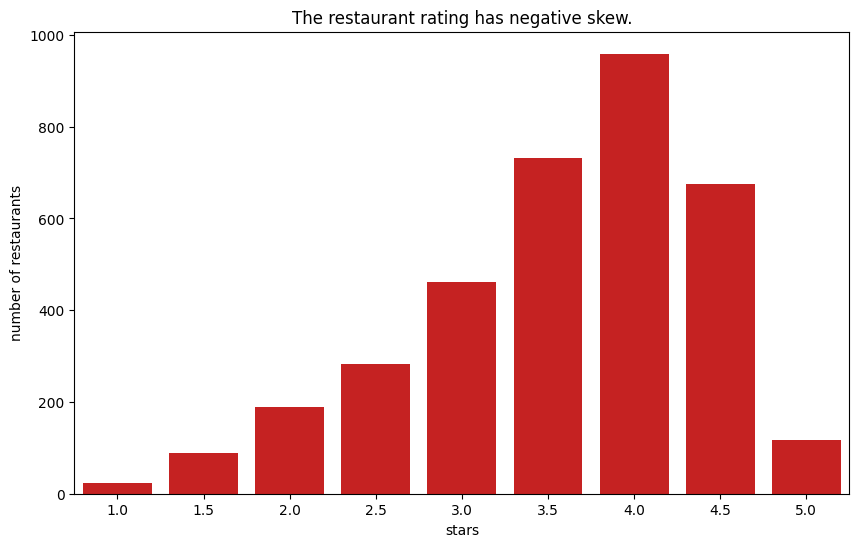

In [39]:
plt.figure(figsize=(10, 6))
cplot = sns.countplot(data=business, x="stars", color=YELP_RED)
cplot.set_ylabel("number of restaurants")
plt.title("The restaurant rating has negative skew.")
plt.show()

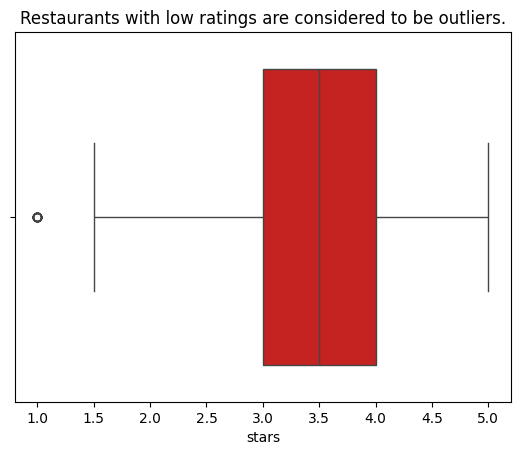

In [40]:
sns.boxplot(data=business, x="stars", color=YELP_RED)
plt.title("Restaurants with low ratings are considered to be outliers.")
plt.show()

#### Review Count

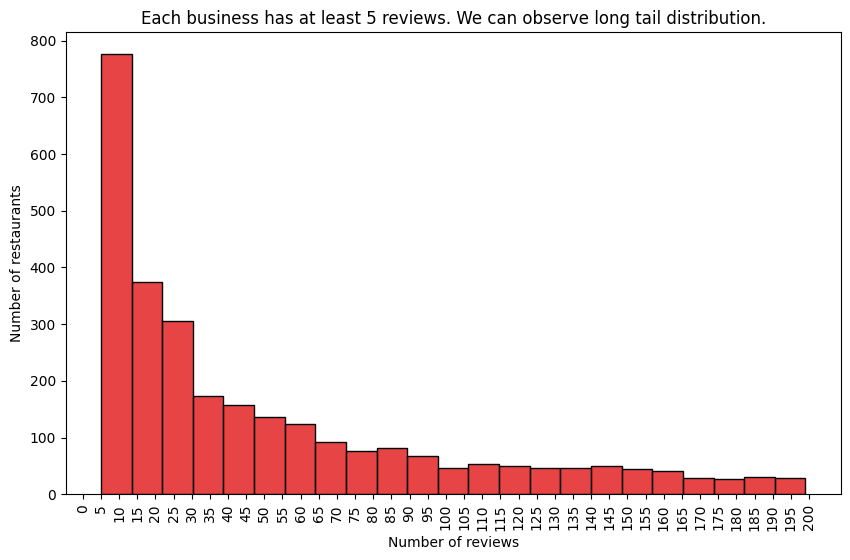

In [41]:
plt.figure(figsize=(10, 6))
review_histplot = sns.histplot(data=business[business["review_count"] < 200], x="review_count", color=YELP_RED)
review_histplot.set_xticks(range(0, 205, 5))
review_histplot.set_xlabel("Number of reviews")
review_histplot.set_ylabel("Number of restaurants")
review_histplot.set_title("Each business has at least 5 reviews. We can observe long tail distribution.")
plt.xticks(rotation=90)
plt.show()

#### Business types (categories)

In [42]:
popular_categories = business.filter(like="_category", axis=1).sum(axis=0, numeric_only=True).sort_values(ascending=False)
popular_categories_df = pd.DataFrame(
    {
        "category": popular_categories.index,
        "count": popular_categories.values,
        "count(%)": (100 * popular_categories / len(business)).values
    }
)
popular_categories_df["category"] = popular_categories_df["category"].apply(lambda x: x[:-9])
# with pd.option_context(
#     'display.max_rows', None,
#     'display.max_columns', None,
#     'display.precision', 3,
#     ):
#     display(popular_categories_df)

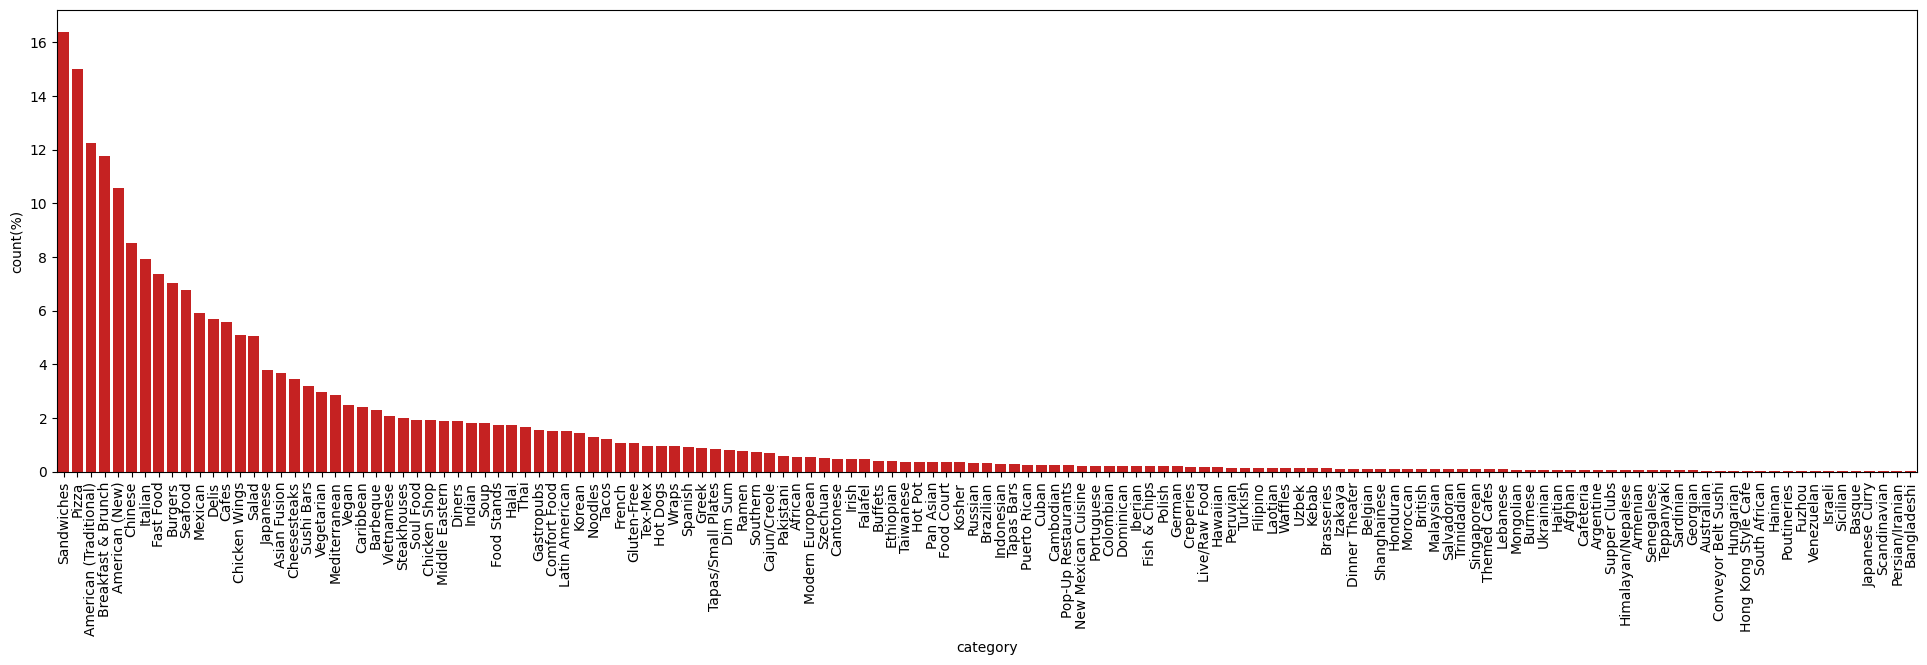

In [43]:
plt.figure(figsize=(24, 6))
categories_barplot = sns.barplot(data=popular_categories_df, x="category", y="count(%)", color=YELP_RED)
plt.xticks(rotation=90)
plt.show()

#### Attributes

In [44]:
business_attributes_df = business.filter(like="_attribute").fillna("no_info")
business_attributes_df

,RestaurantsTakeOut_attribute,OutdoorSeating_attribute,BestNightsFriday_attribute,GoodForMealBreakfast_attribute,AmbienceHipster_attribute,GoodForMealDinner_attribute,AgesAllowed_attribute,AmbienceIntimate_attribute,DietaryRestrictionsVegan_attribute,RestaurantsTableService_attribute,...,BestNightsSaturday_attribute,DietaryRestrictionsDairy-free_attribute,DogsAllowed_attribute,AcceptsInsurance_attribute,RestaurantsPriceRange2_attribute,Corkage_attribute,AmbienceDivey_attribute,GoodForDancing_attribute,BusinessParking_attribute,Open24Hours_attribute
0,True,False,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,...,no_info,no_info,no_info,no_info,1,no_info,no_info,no_info,no_info,no_info
1,True,True,no_info,no_info,False,True,no_info,False,no_info,True,...,no_info,no_info,False,no_info,2,no_info,False,no_info,no_info,no_info
2,True,no_info,no_info,False,False,True,no_info,no_info,no_info,True,...,no_info,no_info,no_info,no_info,1,no_info,False,no_info,no_info,no_info
3,True,True,no_info,False,False,False,no_info,False,no_info,no_info,...,no_info,no_info,True,no_info,2,no_info,False,no_info,no_info,no_info
4,True,False,no_info,no_info,False,no_info,no_info,False,no_info,no_info,...,no_info,no_info,no_info,no_info,1,no_info,False,no_info,no_info,no_info
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3520,True,True,no_info,no_info,no_info,True,no_info,no_info,no_info,True,...,no_info,no_info,False,no_info,2,no_info,False,no_info,no_info,no_info
3521,True,False,no_info,no_info,no_info,no_info,no_info,no_info,no_info,False,...,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info
3522,True,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,...,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info,no_info
3523,True,False,no_info,False,False,True,no_info,False,no_info,no_info,...,no_info,no_info,no_info,no_info,2,no_info,False,no_info,no_info,no_info


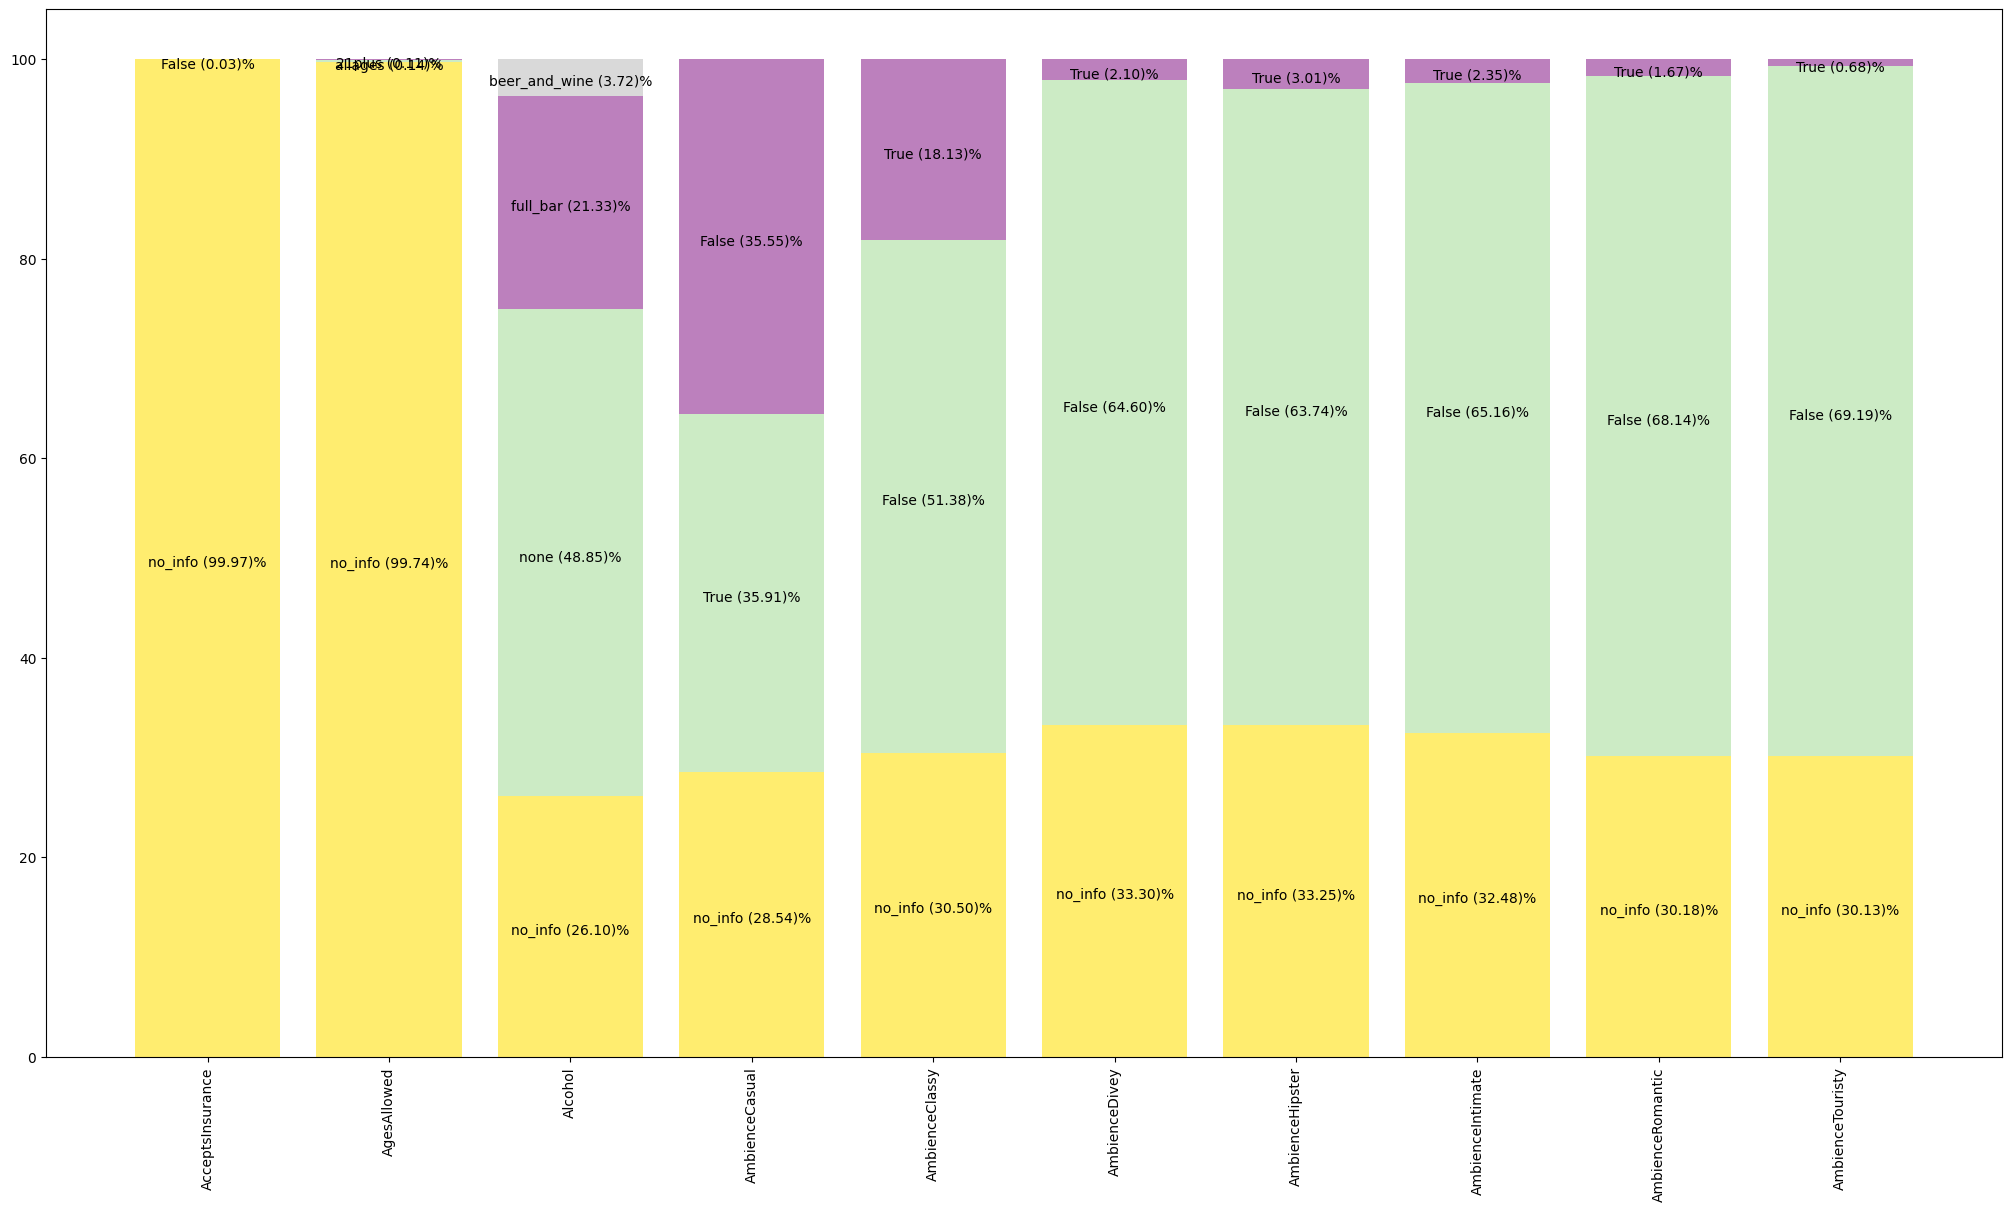

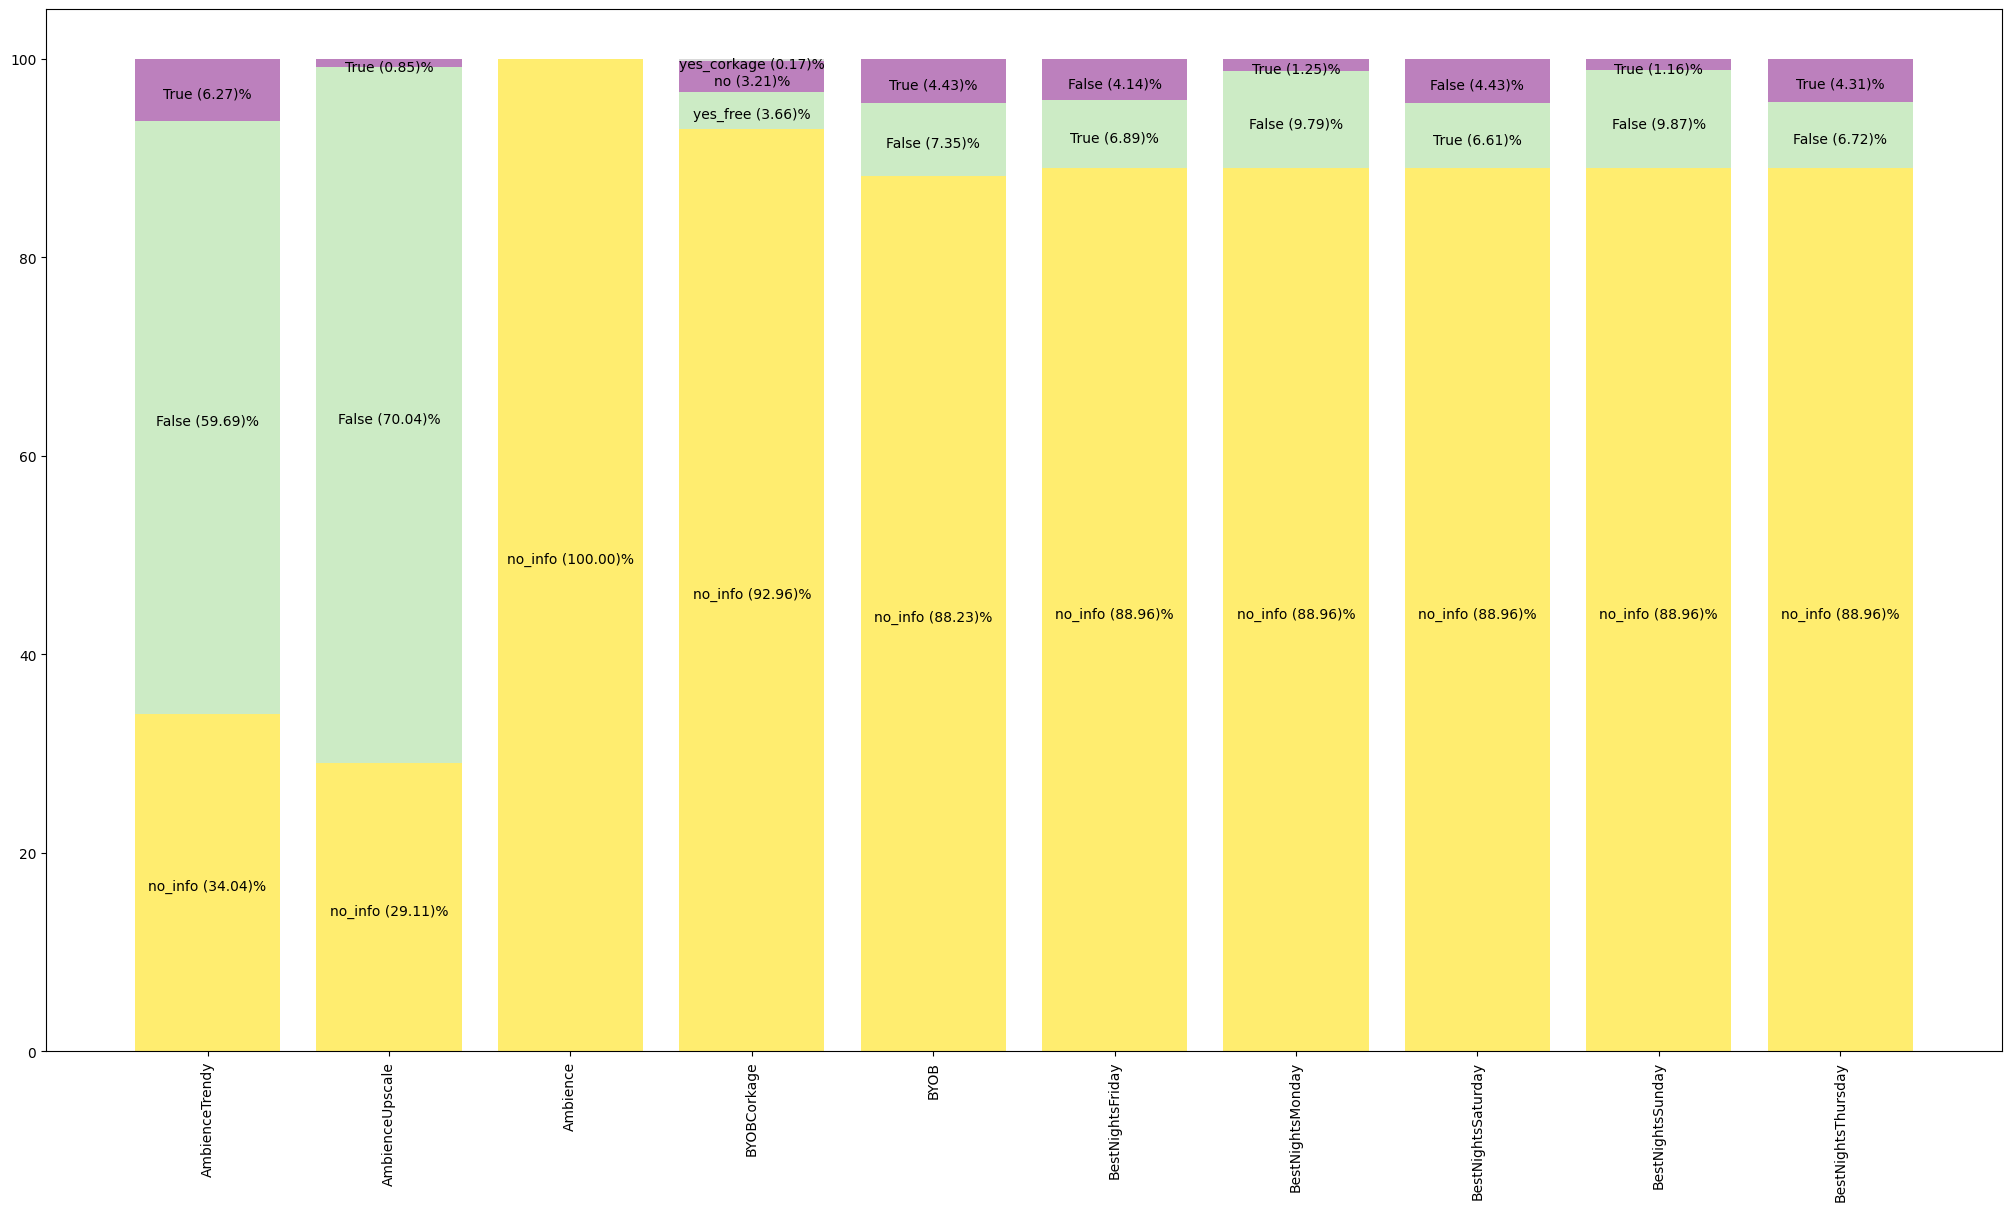

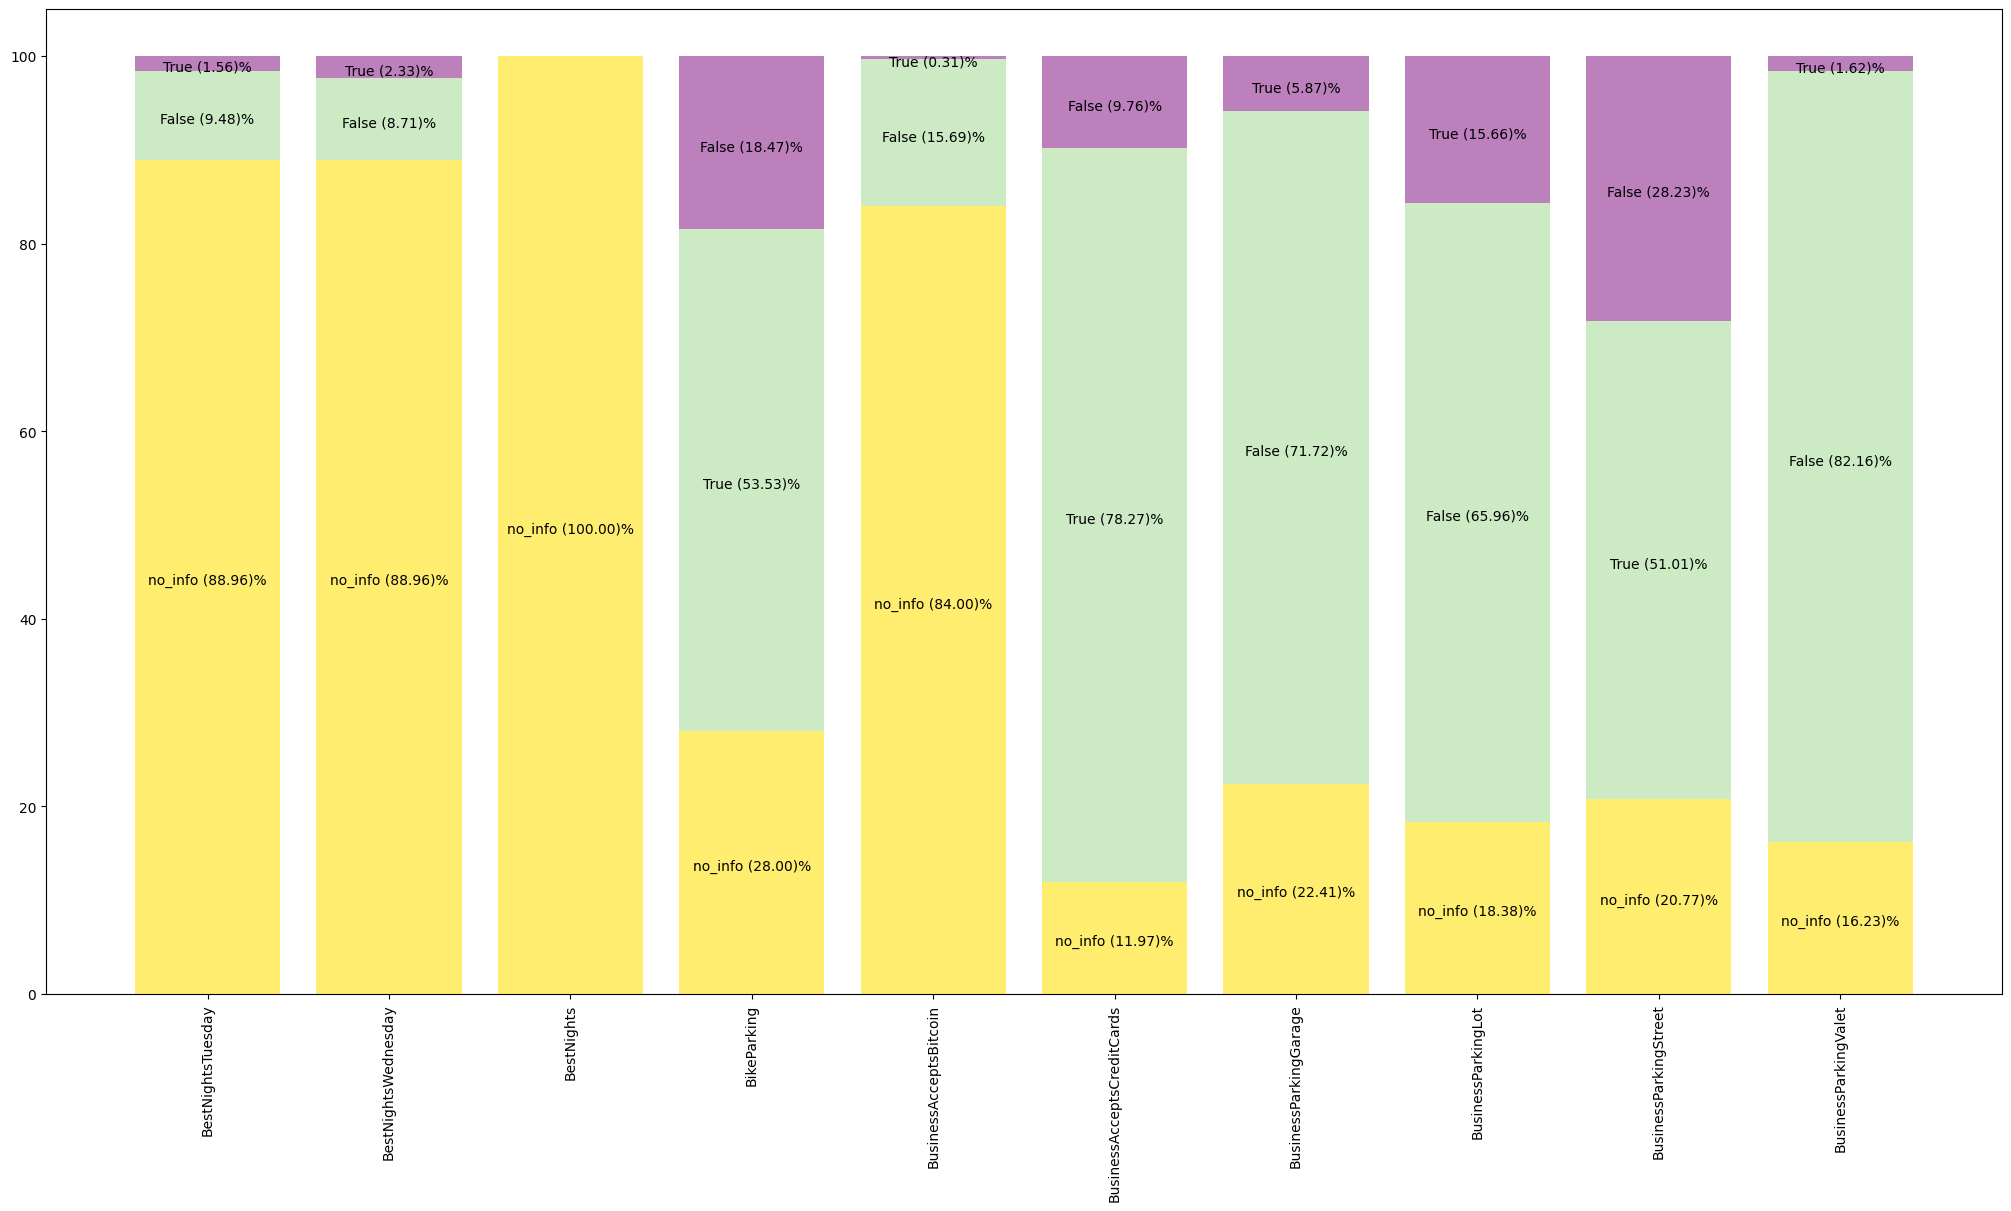

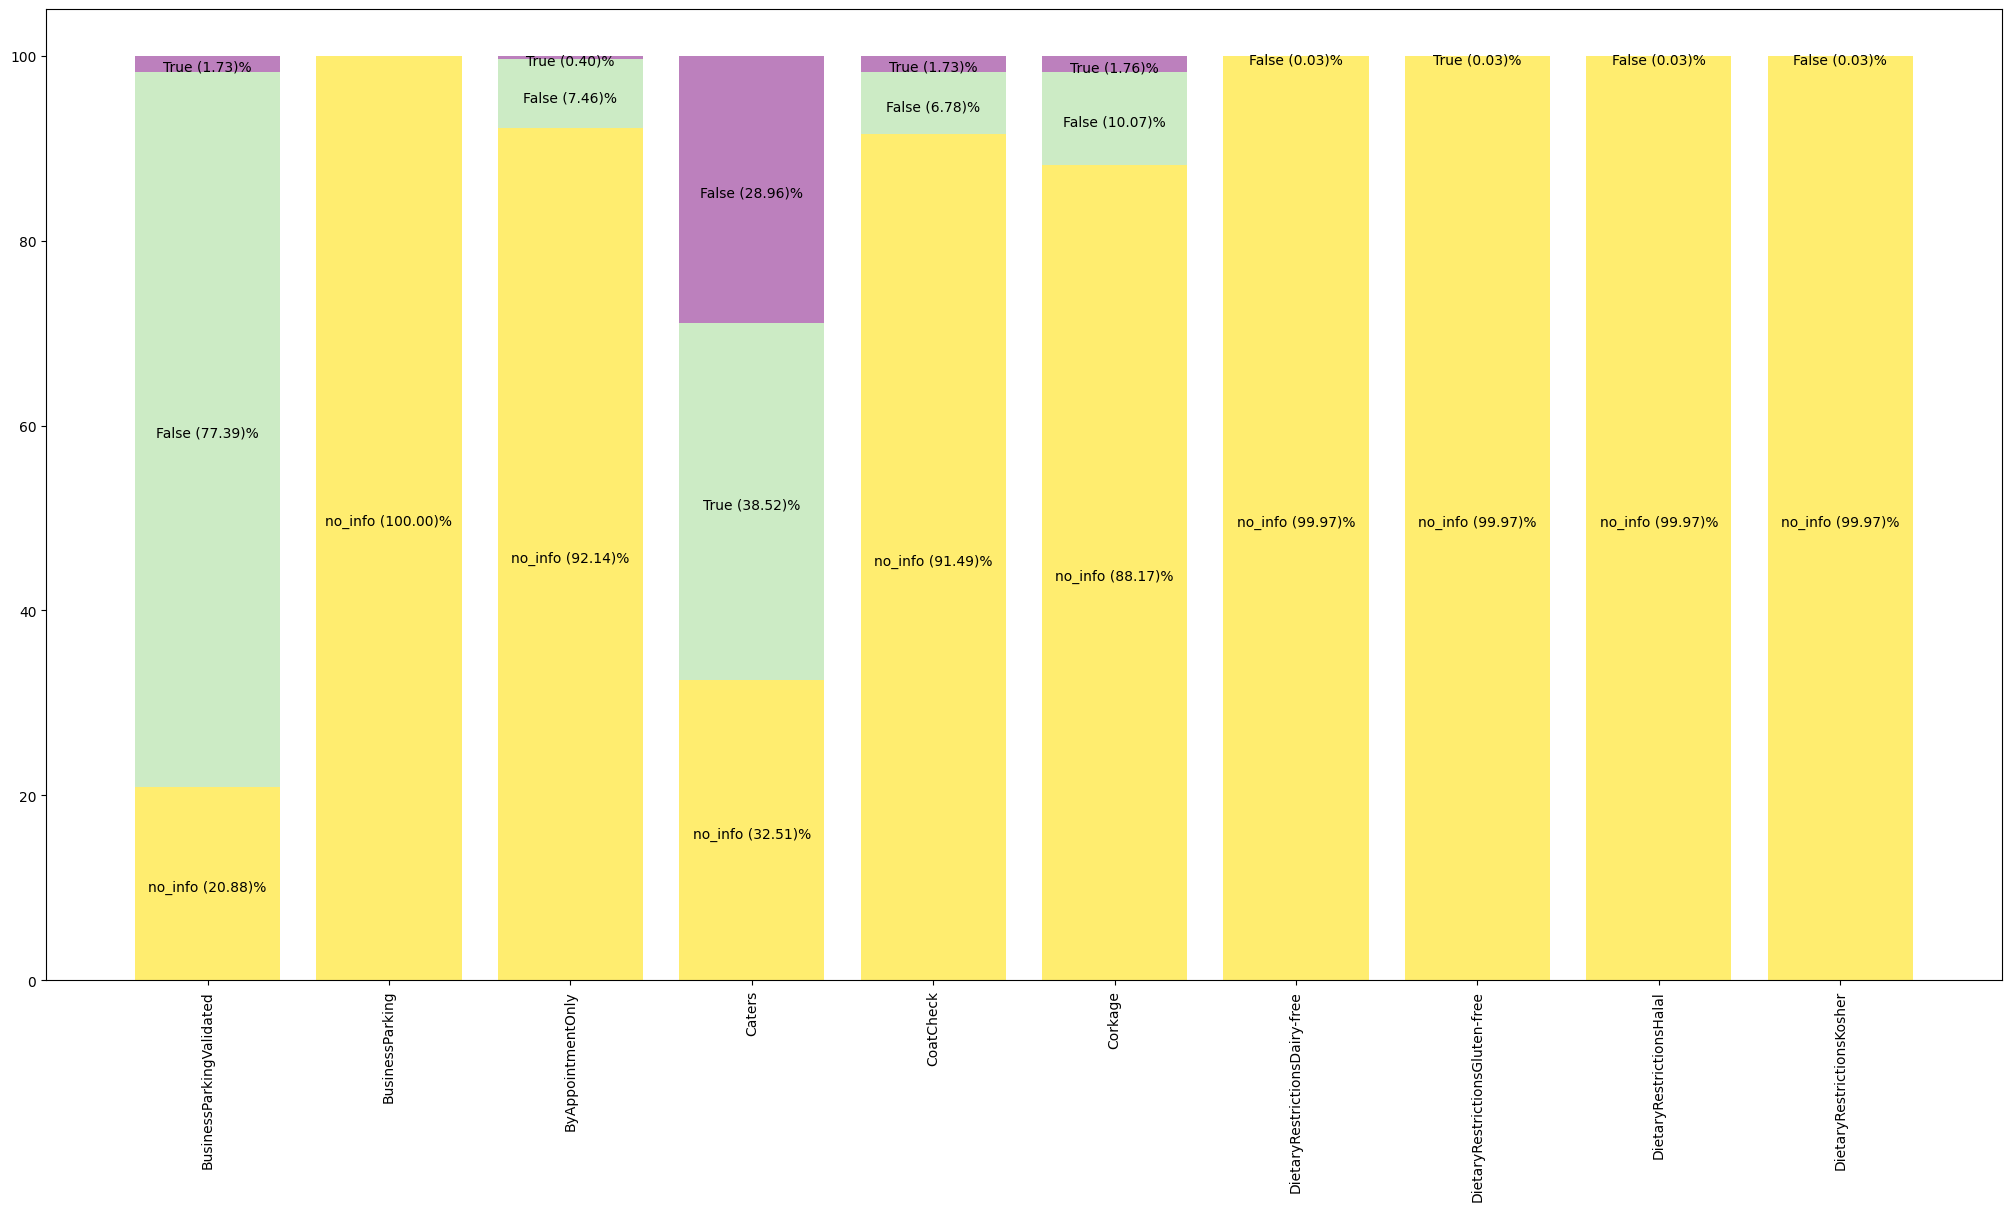

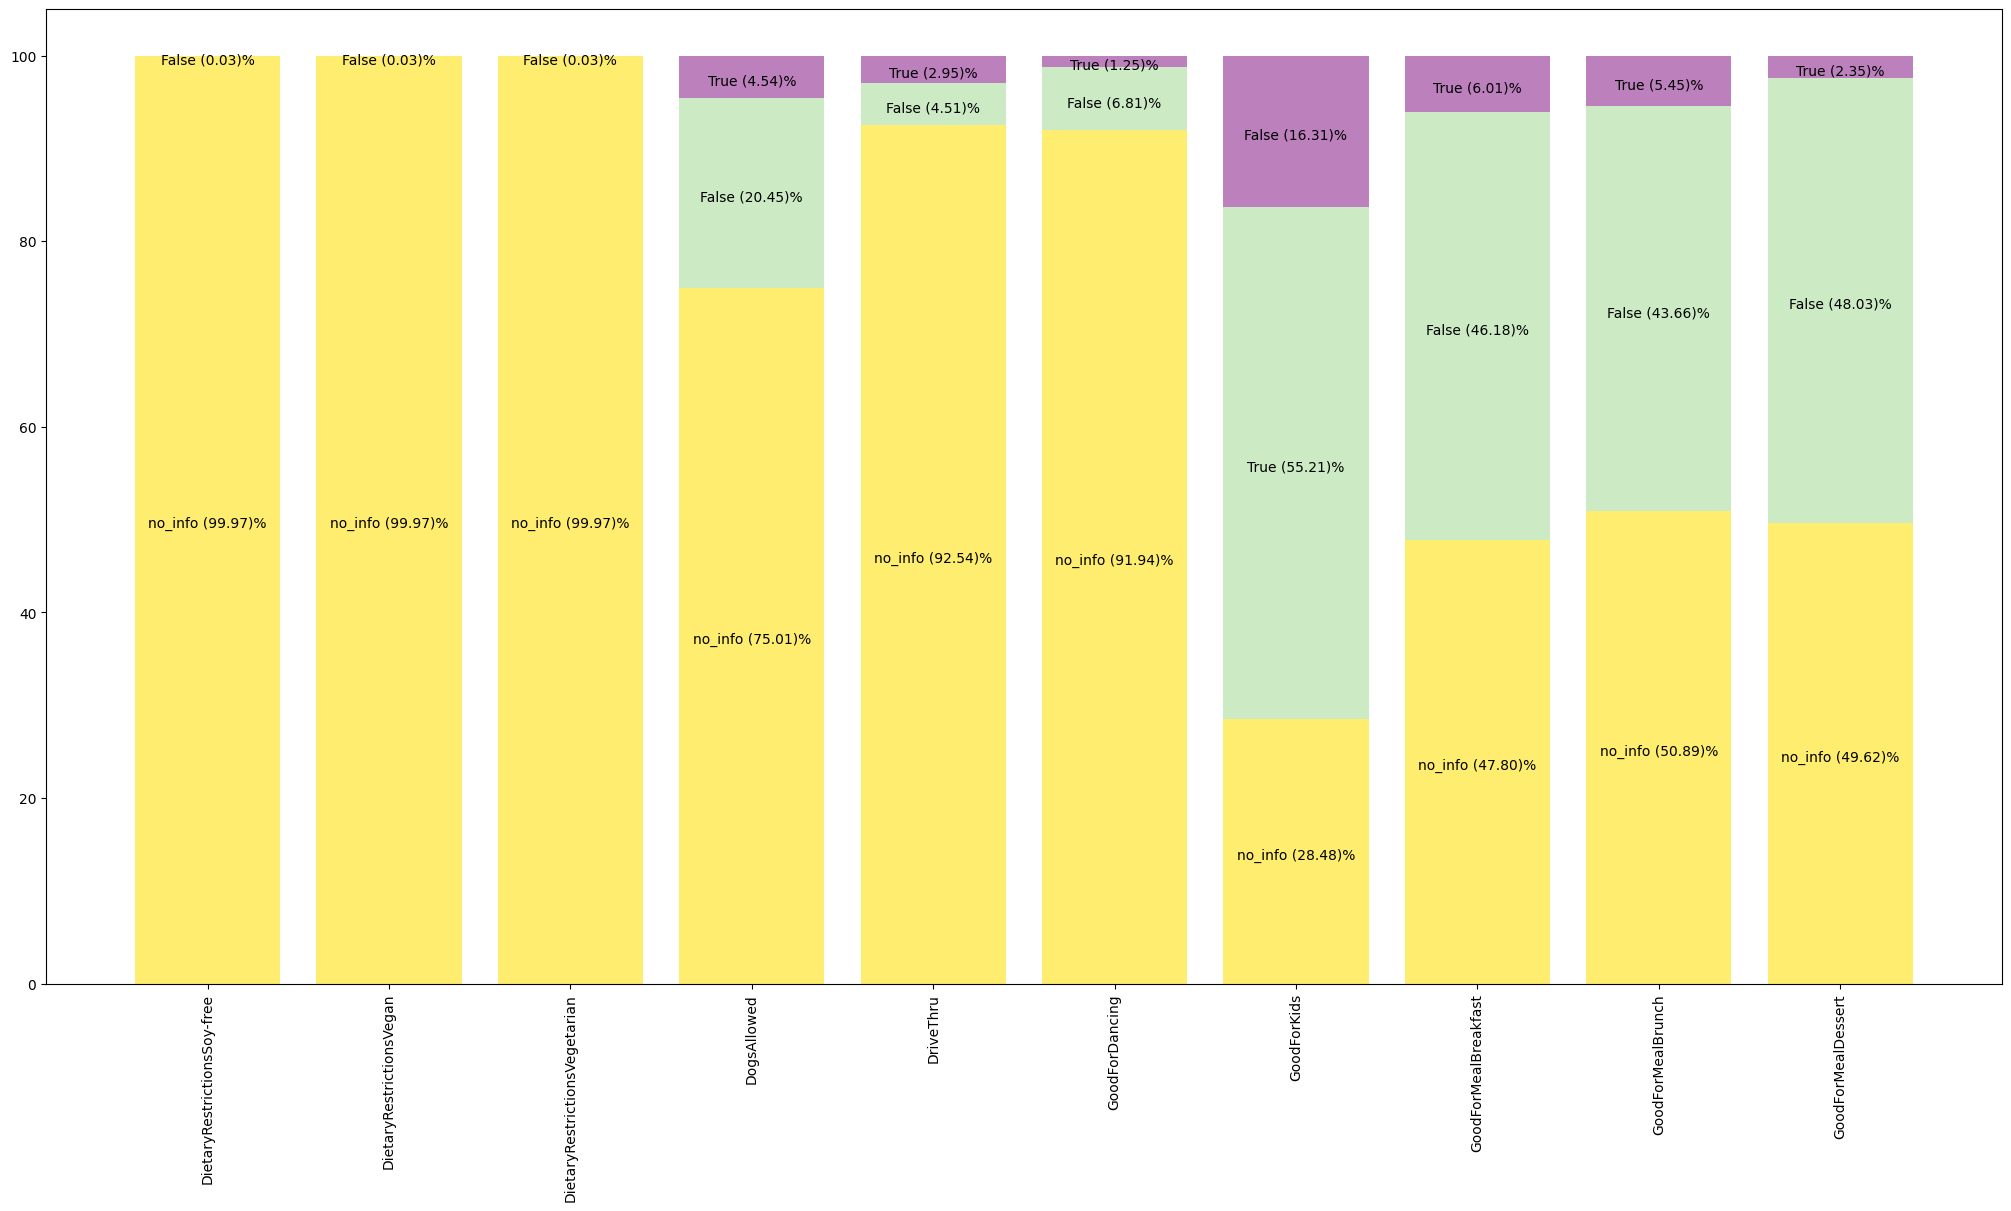

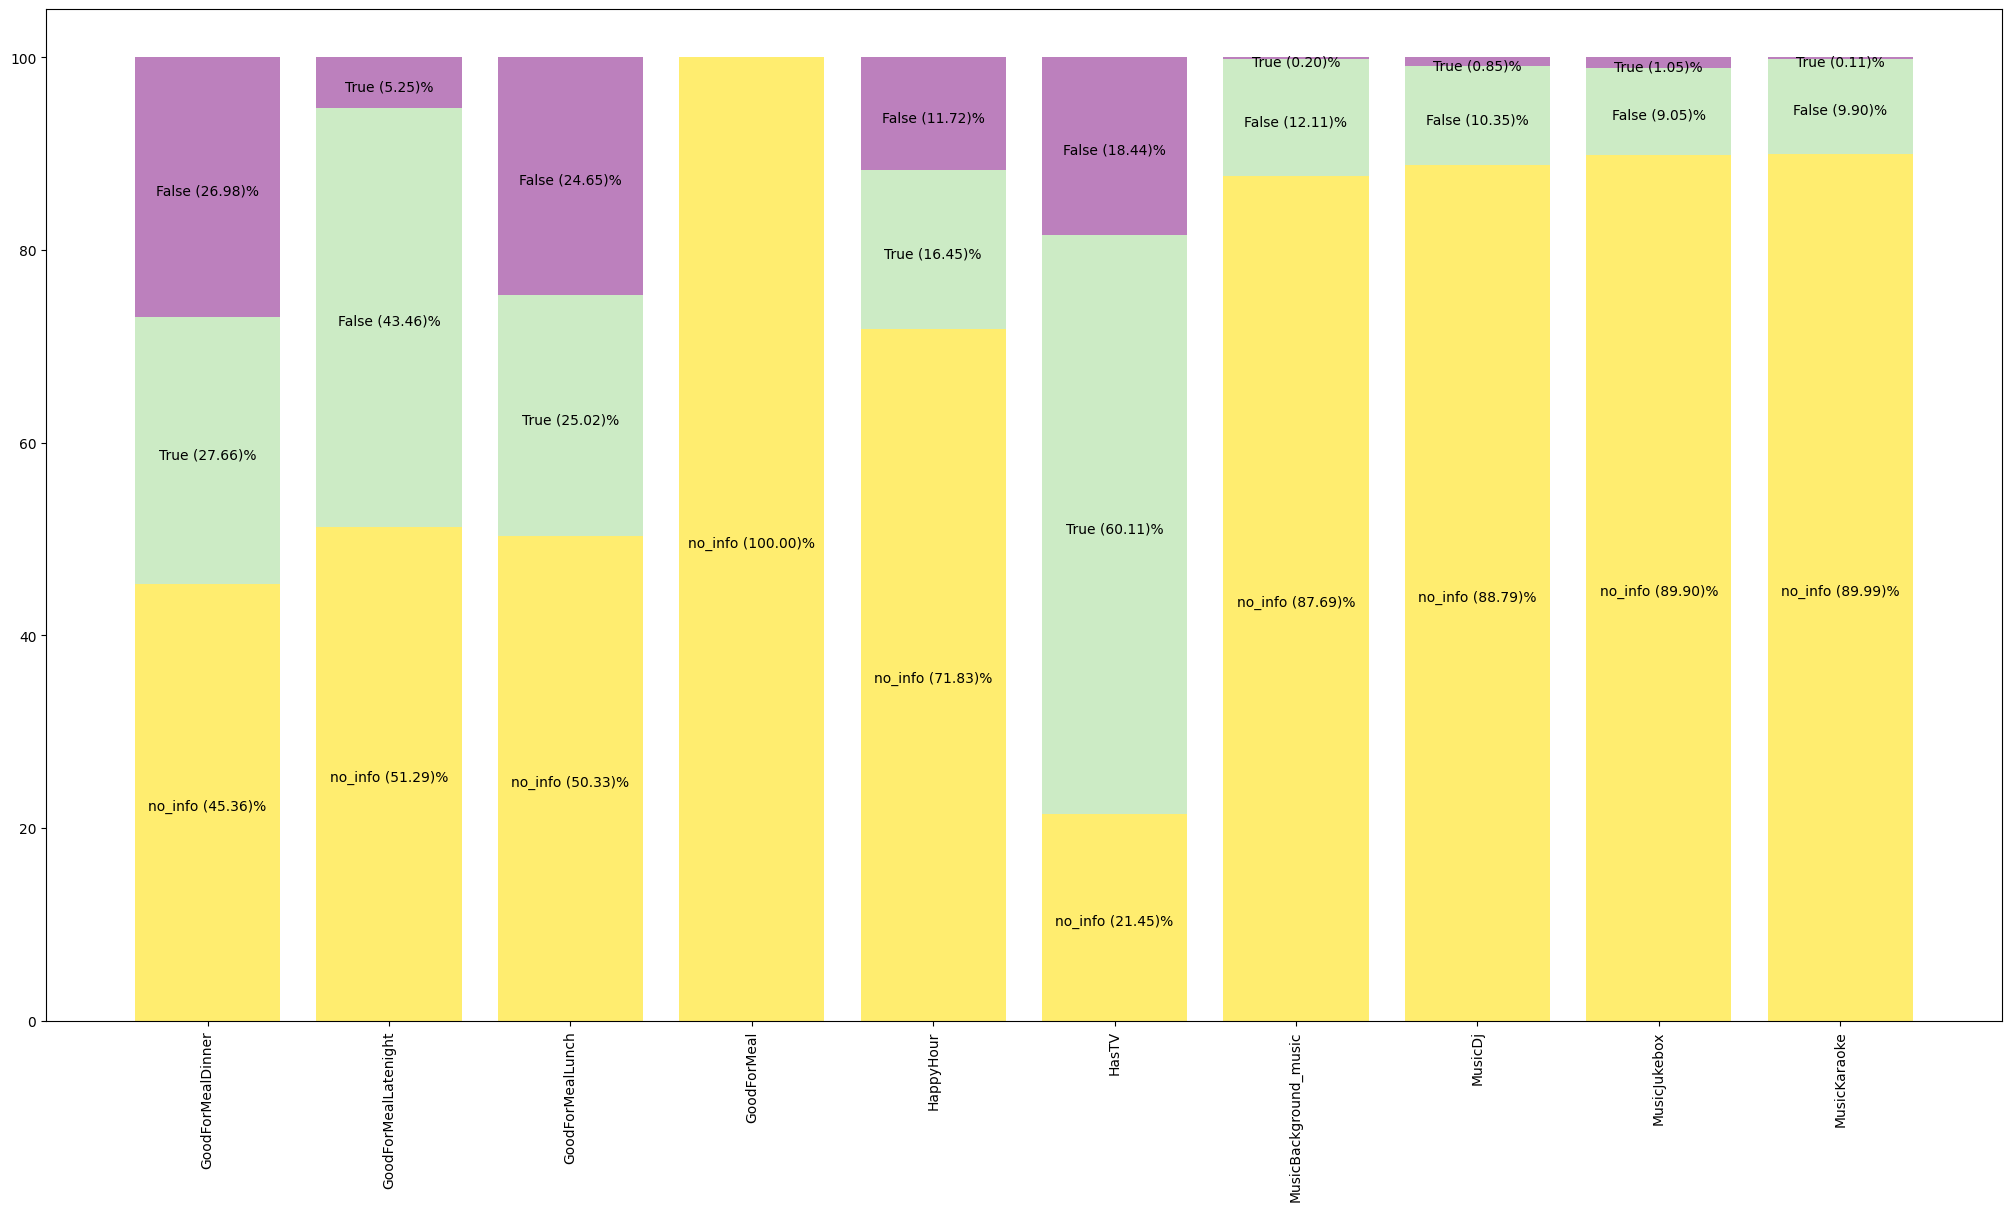

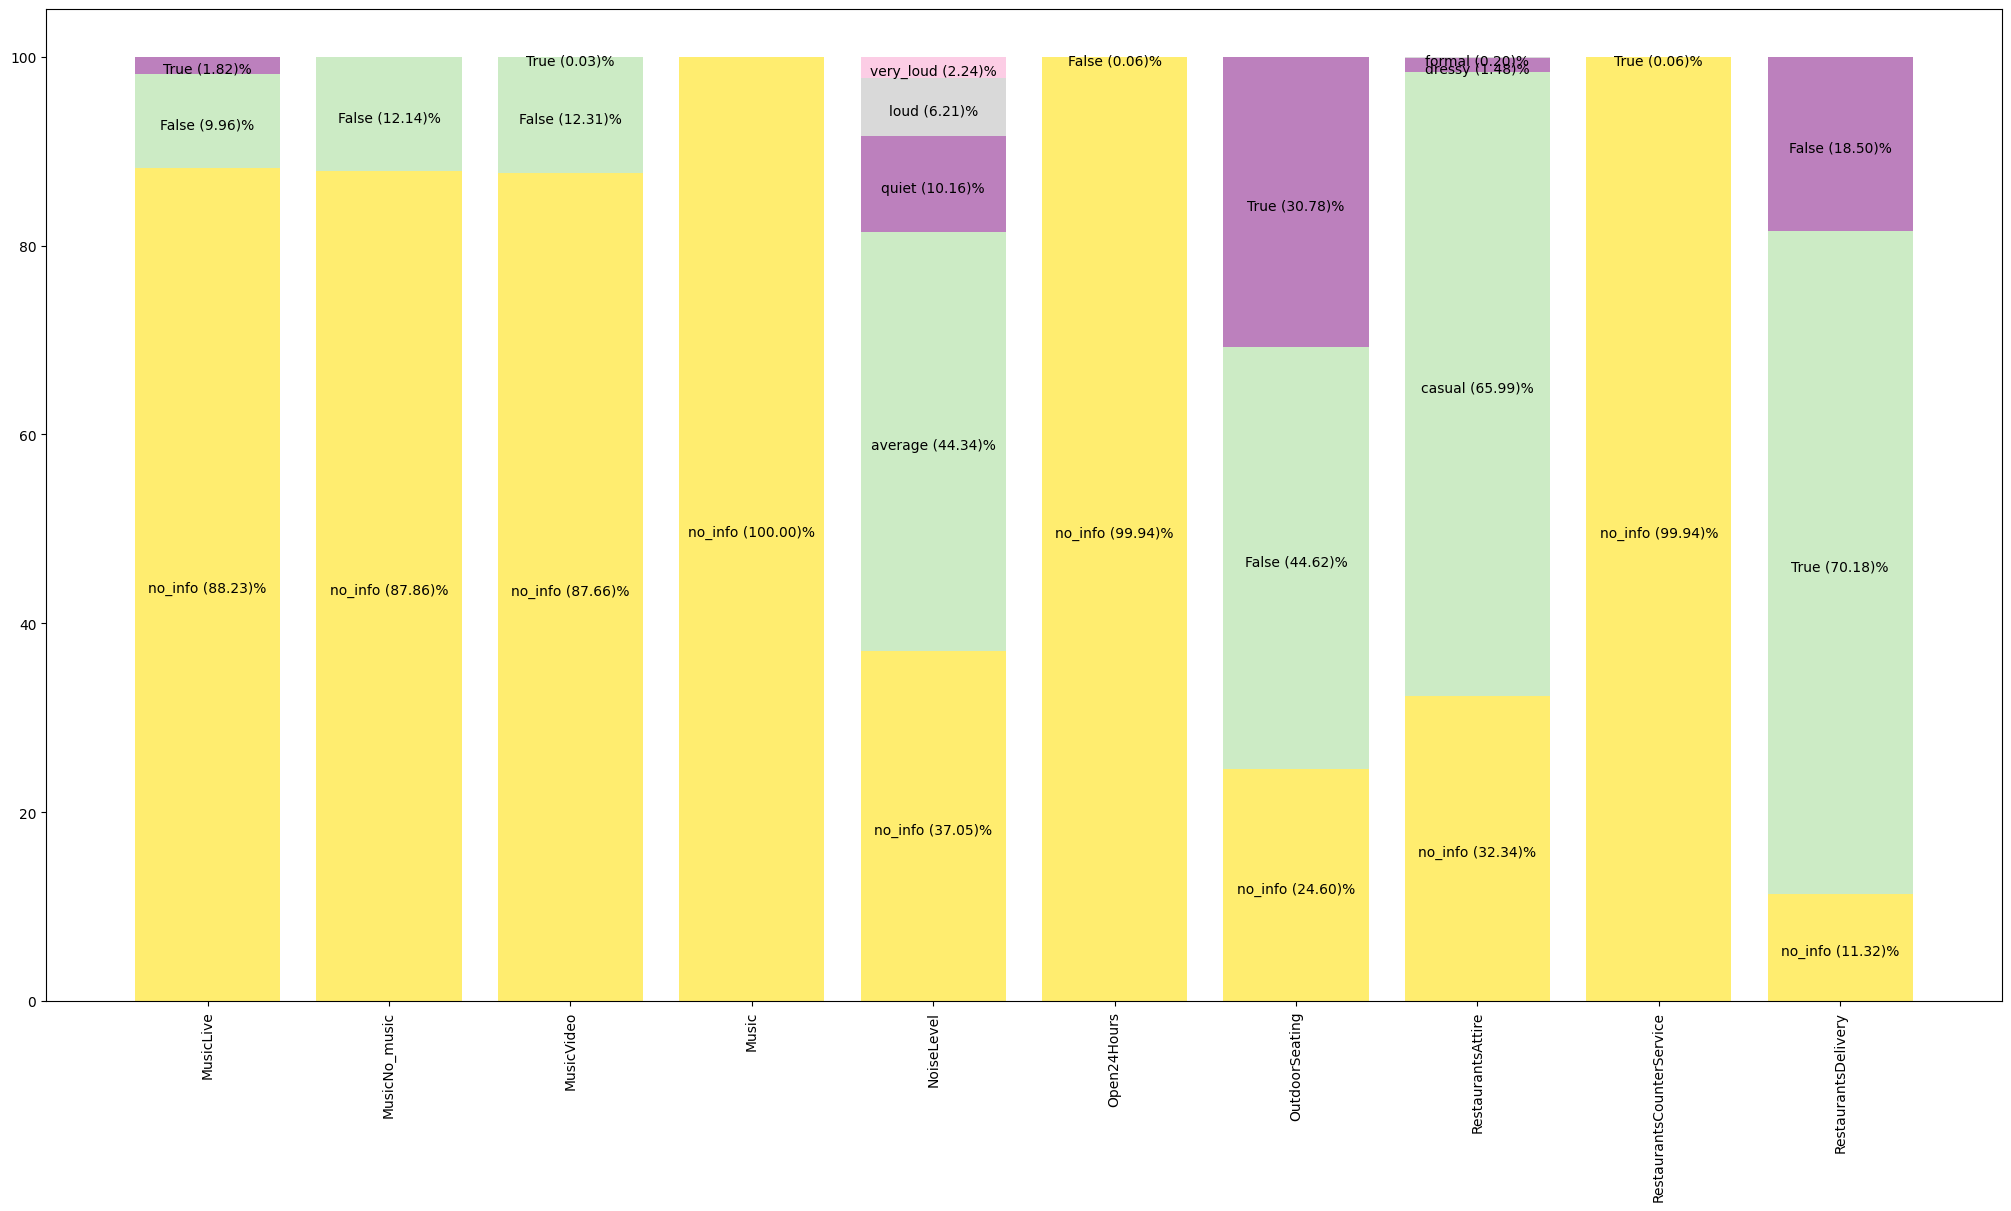

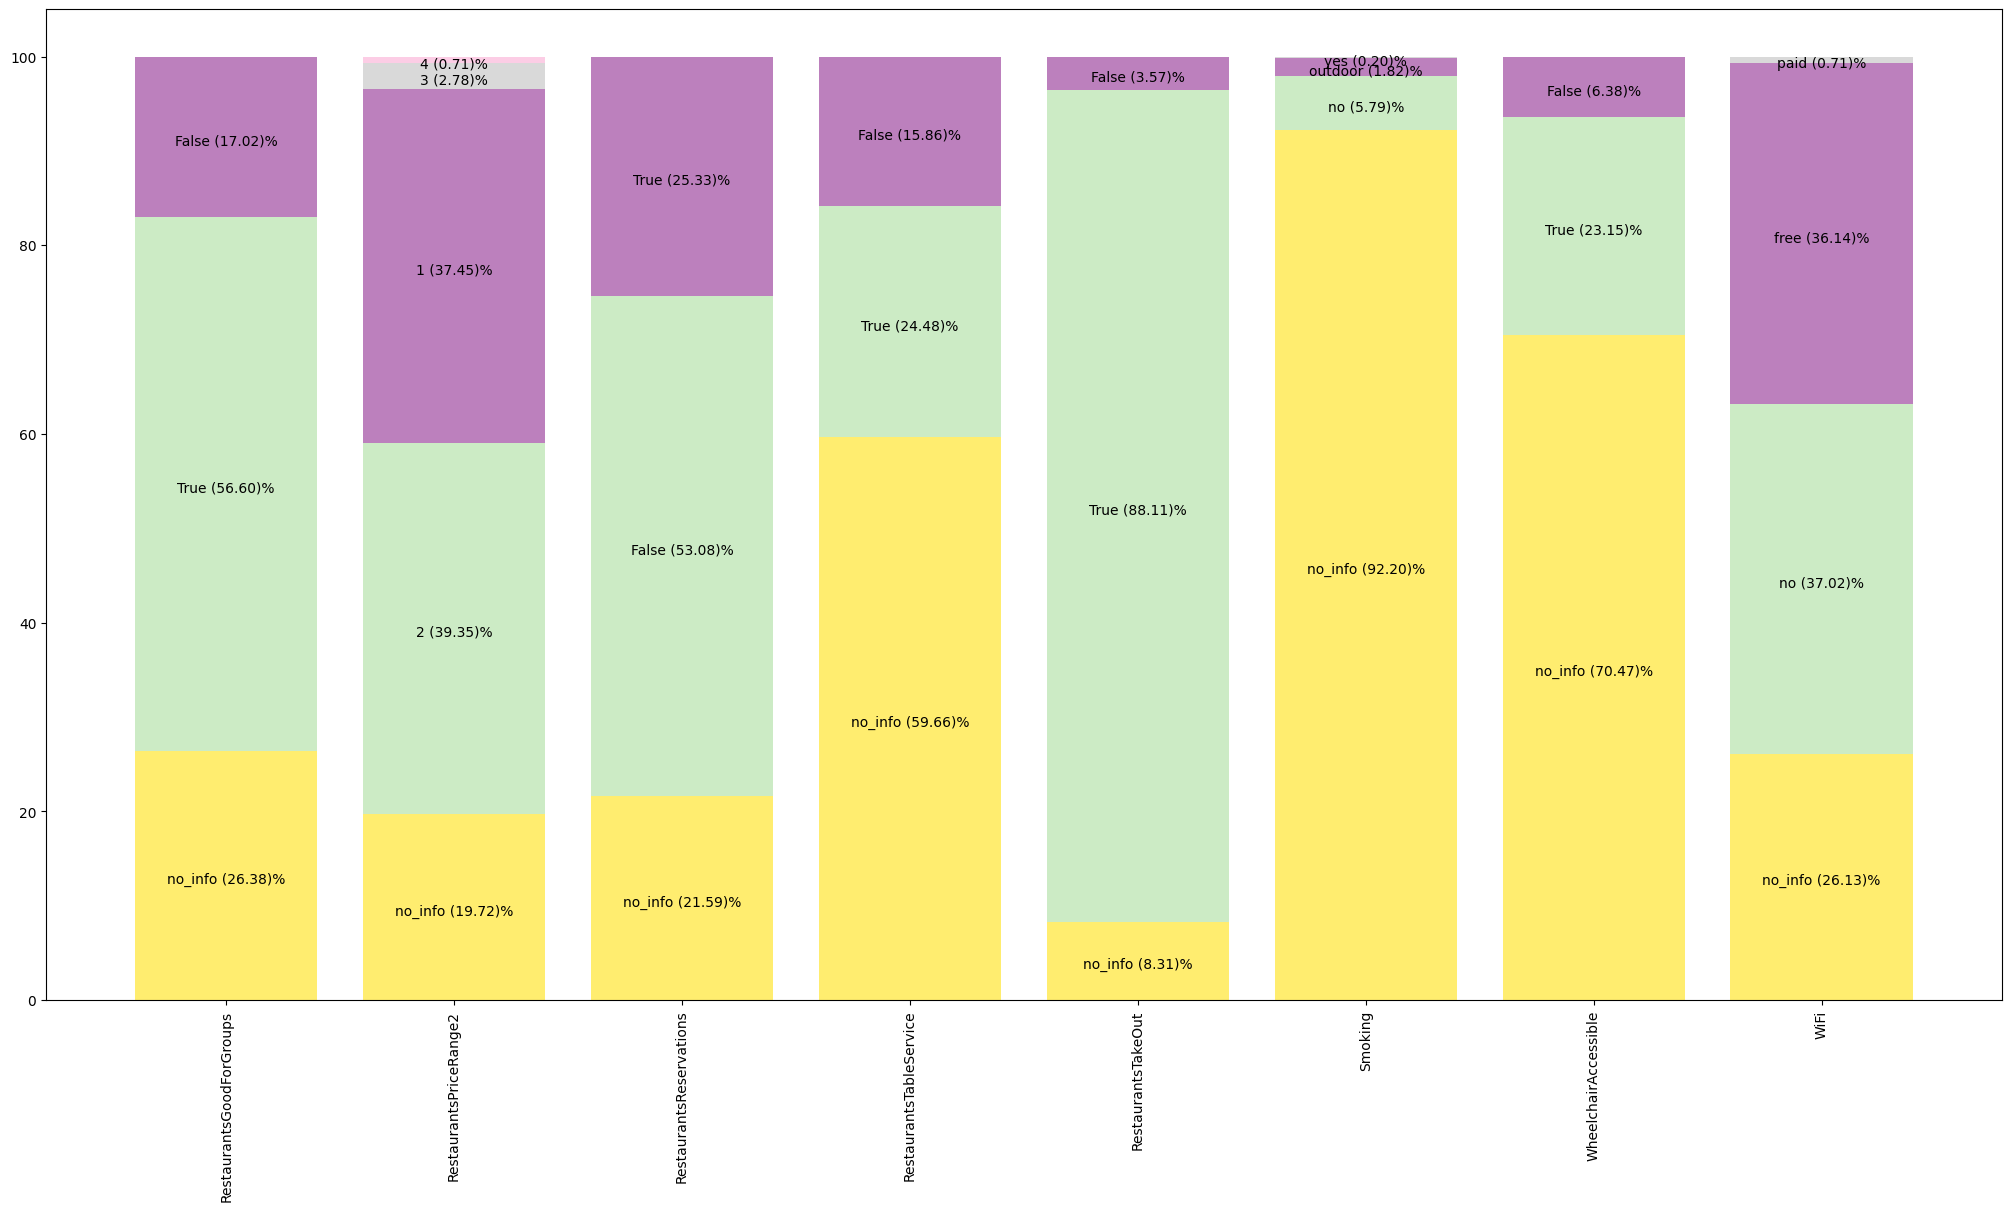

In [45]:
for i in range(10, len(business_attributes_df.columns)+10, 10):
    fig, ax = plt.subplots(figsize=(20,12), layout='constrained')
    for attribute in sorted(list(business_attributes_df.columns))[i-10:i]:                                    ##
        vc = business_attributes_df.value_counts(attribute)
        to_add = vc["no_info"]
        vc.drop(labels="no_info", inplace=True)
        vc = pd.concat([pd.Series([to_add], index=['no_info']), vc])
        colors=sns.color_palette("Set3")[:]
        bottom = 0
        for label, count_percentage in (100 * vc / vc.sum()).items():
            bars = ax.bar(attribute[:-10], count_percentage, label=label, bottom=bottom, lw=0.5, color=colors.pop())
            for bar in bars:
                h, w, x, y = bar._height, bar._width, bar._x0, bar._y0
                ax.text(
                    x+w/2,
                    y+h/2-0.4,
                    f"{label} ({h:.2f})%",
                    ha='center',
                    va='center',
                    fontsize=10,
                    # weight='bold',
                    color='black'
                )
            bottom += count_percentage
    # plt.title("Category percentages month by month")

    plt.xticks(rotation=90)
    plt.show()


In [ ]:
# for col in list(business_attributes_df.columns):
#     vc = business_attributes_df.value_counts(col)
#     vc_no_dict = vc.drop("no_info")
# 
#     if len(vc_no_dict) != 0:
#         fig, (ax_vc, ax_vc_no_dict) = plt.subplots(1, 2, figsize=(16, 6))
#         ax_vc.pie(
#             vc.to_list(),
#             labels=vc.index.to_list(),
#             colors=sns.color_palette("Set3")[:],
#             # autopct=make_autopct(vc.to_list()),
#             autopct="%0.2f%%",
#         )
#         ax_vc_no_dict.pie(
#             vc_no_dict.to_list(),
#             labels=vc_no_dict.index.to_list(),
#             colors=sns.color_palette("Set3")[1:],
#             # autopct=make_autopct(vc.to_list()),
#             autopct="%0.2f%%",
#         )
#         fig.suptitle(col)
#         plt.show()

In [46]:
business = business.drop(labels=list(business.filter(like="_attribute").columns), axis=1)

In [47]:
attributes_one_hot = pd.get_dummies(data=business_attributes_df, dtype=int)
display(attributes_one_hot)

,RestaurantsTakeOut_attribute_False,RestaurantsTakeOut_attribute_True,RestaurantsTakeOut_attribute_no_info,OutdoorSeating_attribute_False,OutdoorSeating_attribute_True,OutdoorSeating_attribute_no_info,BestNightsFriday_attribute_False,BestNightsFriday_attribute_True,BestNightsFriday_attribute_no_info,GoodForMealBreakfast_attribute_False,...,Corkage_attribute_no_info,AmbienceDivey_attribute_False,AmbienceDivey_attribute_True,AmbienceDivey_attribute_no_info,GoodForDancing_attribute_False,GoodForDancing_attribute_True,GoodForDancing_attribute_no_info,BusinessParking_attribute_no_info,Open24Hours_attribute_False,Open24Hours_attribute_no_info
0,0,1,0,1,0,0,0,0,1,0,...,1,0,0,1,0,0,1,1,0,1
1,0,1,0,0,1,0,0,0,1,0,...,1,1,0,0,0,0,1,1,0,1
2,0,1,0,0,0,1,0,0,1,1,...,1,1,0,0,0,0,1,1,0,1
3,0,1,0,0,1,0,0,0,1,1,...,1,1,0,0,0,0,1,1,0,1
4,0,1,0,1,0,0,0,0,1,0,...,1,1,0,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3520,0,1,0,0,1,0,0,0,1,0,...,1,1,0,0,0,0,1,1,0,1
3521,0,1,0,1,0,0,0,0,1,0,...,1,0,0,1,0,0,1,1,0,1
3522,0,1,0,0,0,1,0,0,1,0,...,1,0,0,1,0,0,1,1,0,1
3523,0,1,0,1,0,0,0,0,1,1,...,1,1,0,0,0,0,1,1,0,1


In [48]:
business = pd.concat([business, attributes_one_hot], axis=1)

In [49]:
business.drop(labels=["name", "address"], axis=1, inplace=True)

In [50]:
business

,business_id,latitude,longitude,stars,review_count,Gluten-Free_category,Modern European_category,Barbeque_category,British_category,Portuguese_category,...,Corkage_attribute_no_info,AmbienceDivey_attribute_False,AmbienceDivey_attribute_True,AmbienceDivey_attribute_no_info,GoodForDancing_attribute_False,GoodForDancing_attribute_True,GoodForDancing_attribute_no_info,BusinessParking_attribute_no_info,Open24Hours_attribute_False,Open24Hours_attribute_no_info
0,MTSW4McQd7CbVtyjqoe9mw,39.955505,-75.155564,4.0,80,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
1,MUTTqe8uqyMdBl186RmNeA,39.953949,-75.143226,4.0,245,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,1
2,ROeacJQwBeh05Rqg7F6TCg,39.943223,-75.162568,4.5,205,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,1
3,aPNXGTDkf-4bjhyMBQxqpQ,39.962582,-75.135657,3.5,65,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,1
4,ppFCk9aQkM338Rgwpl2F5A,39.954573,-75.194894,3.0,56,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3520,auwFZzfhe2pvFw43OfsAfw,39.925205,-75.174728,4.5,112,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,1
3521,K1SsvIPfFcHniNSPc3IG7g,39.970720,-75.157752,4.0,16,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
3522,OfRbGvHn-nAnQMqNxiIpcA,39.957447,-75.189916,3.0,5,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
3523,wVxXRFf10zTTAs11nr4xeA,40.032483,-75.214430,3.0,55,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,1


#### Hours

Now, visualisations of opening times, closing times and length of openings throughout the week.

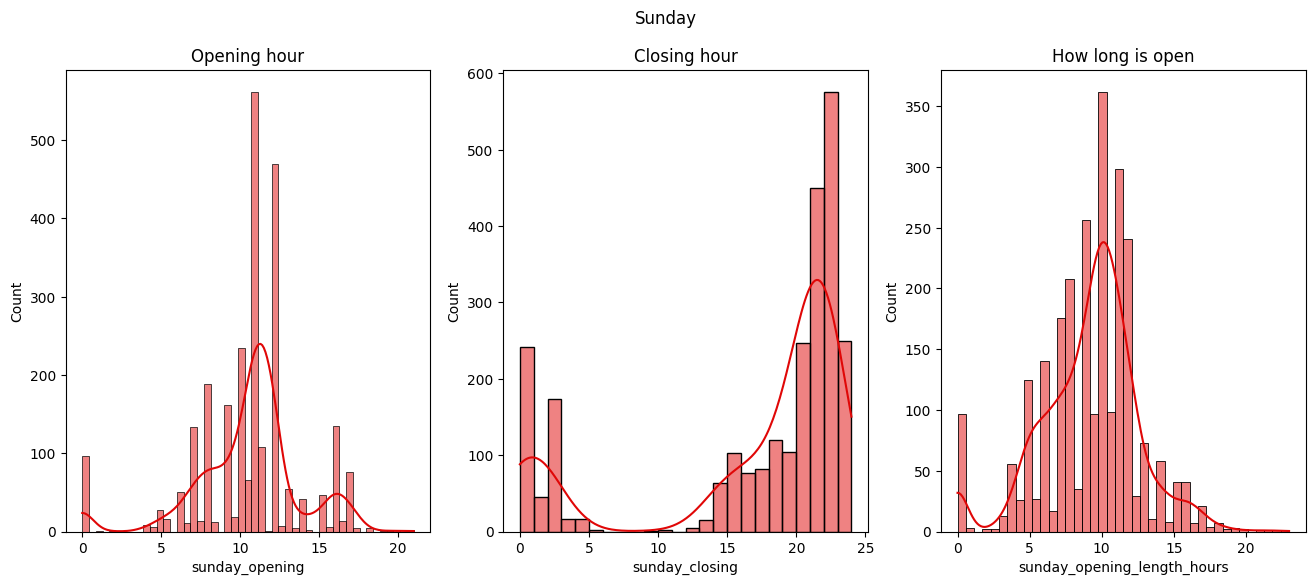

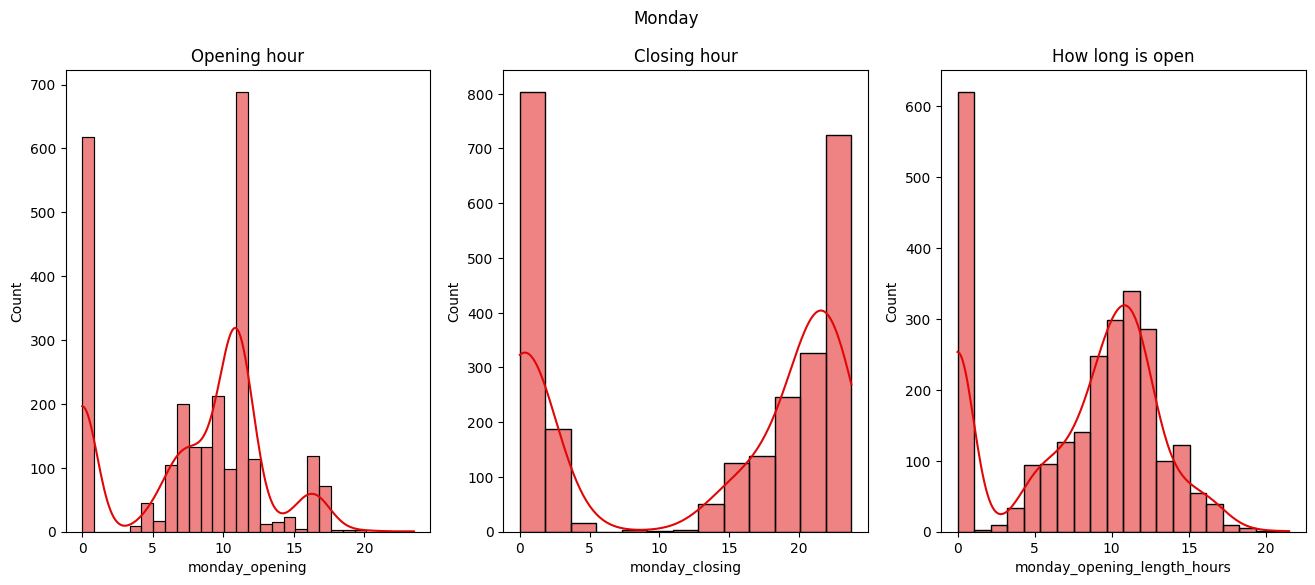

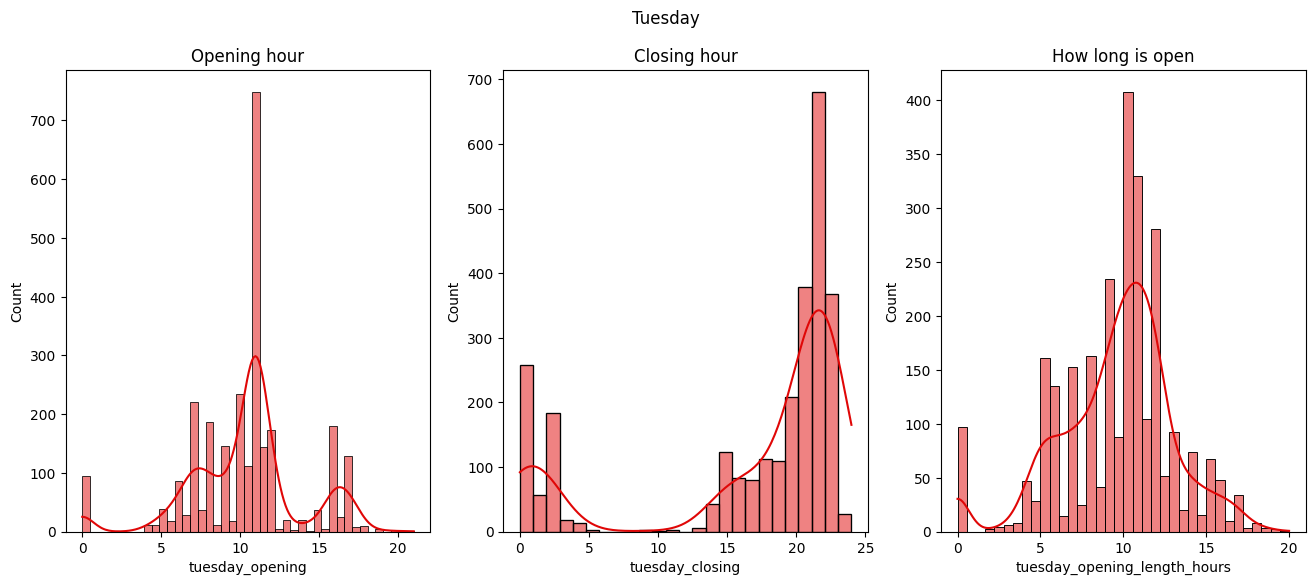

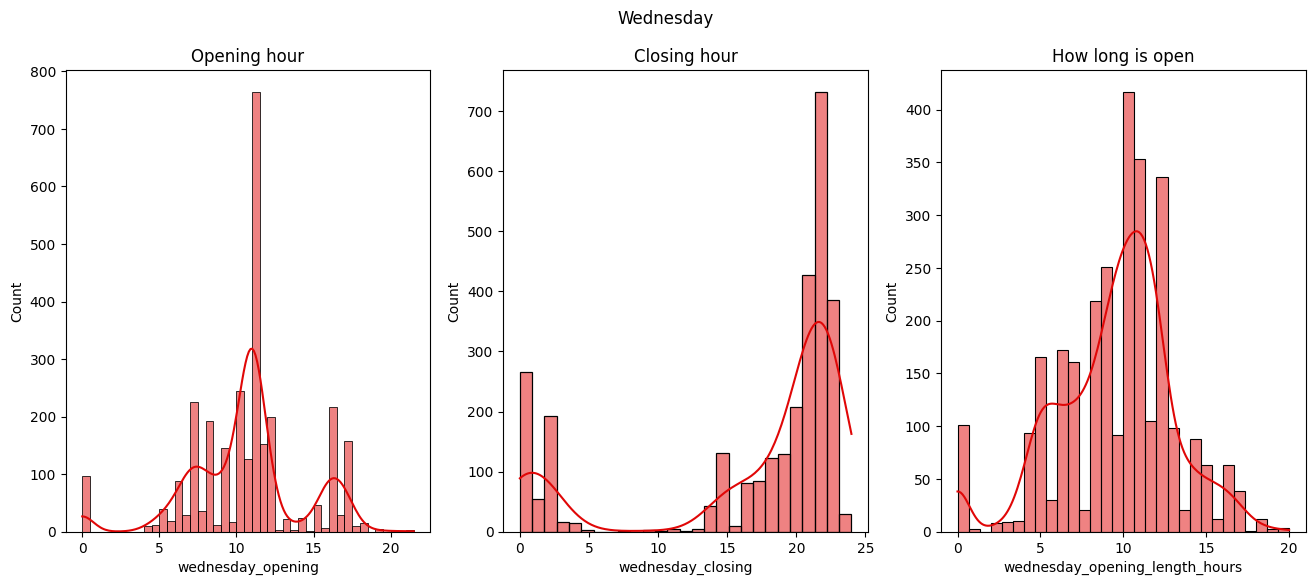

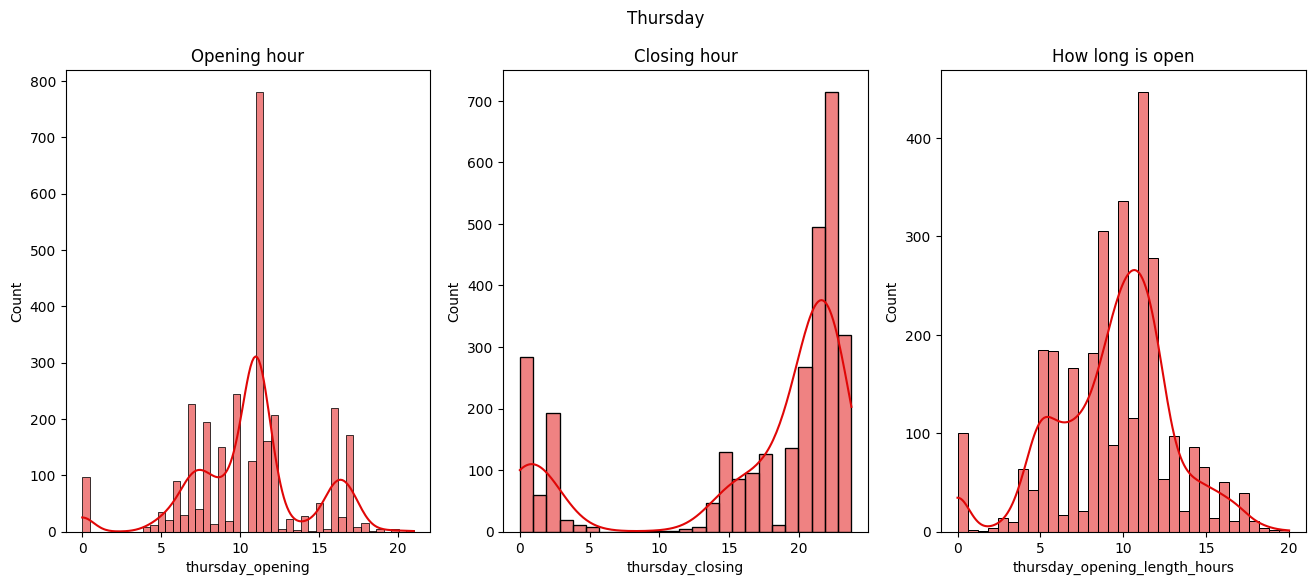

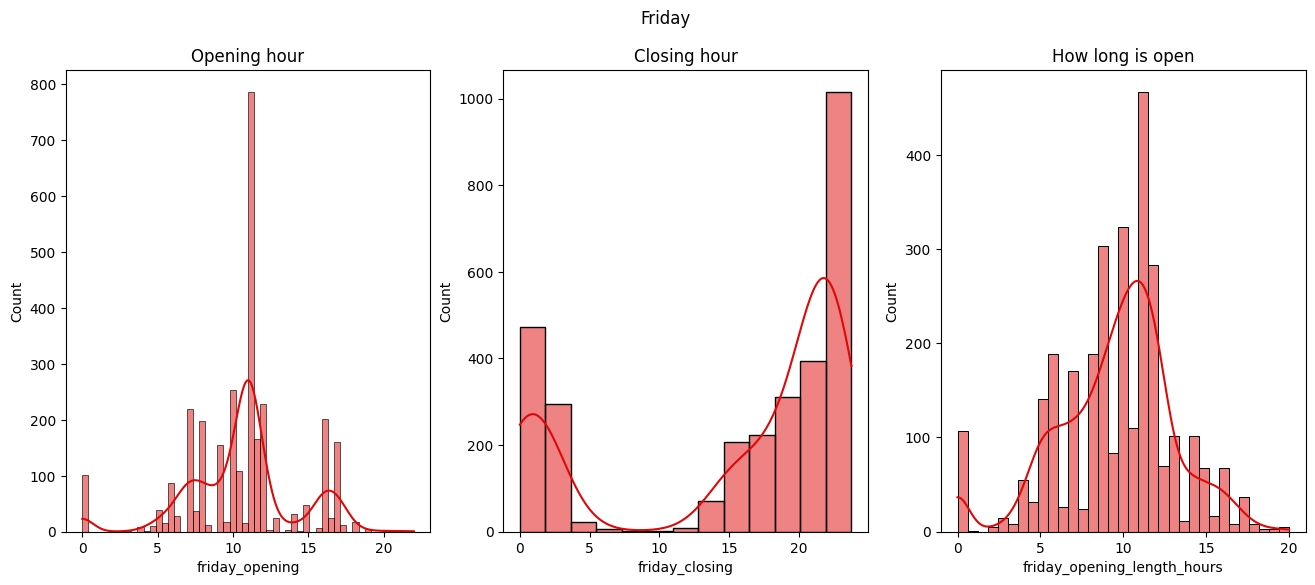

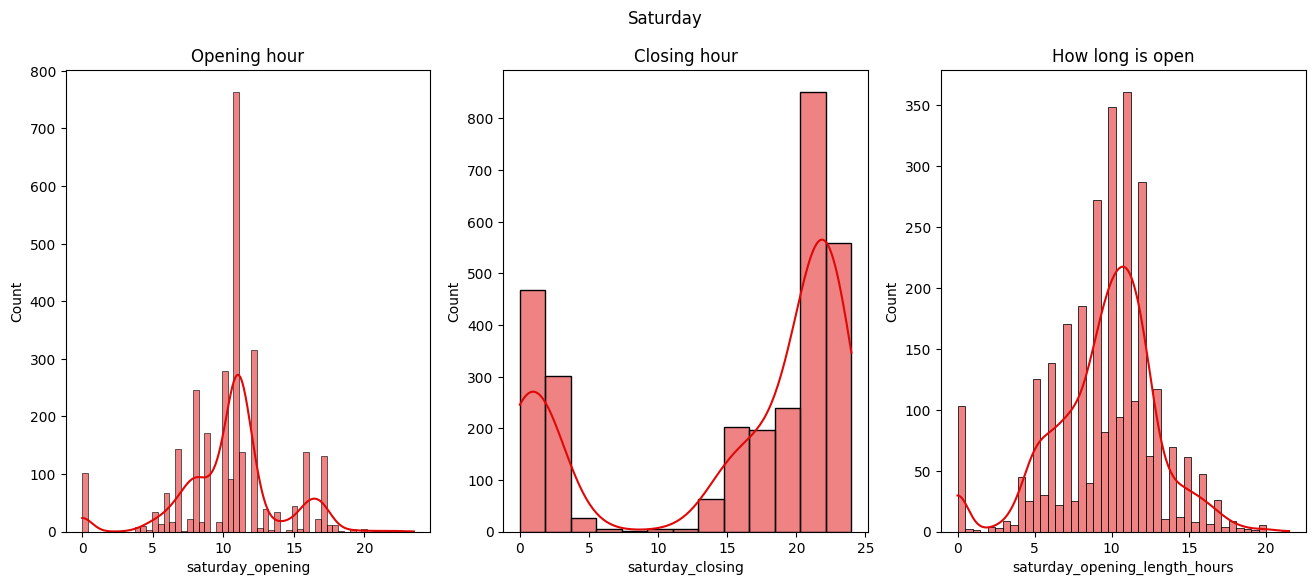

In [51]:
for weekday in weekdays:
    fig, (ax_1, ax_2, ax_3) = plt.subplots(1, 3, figsize=(16, 6))
    sns.histplot(data=business, x=f"{weekday.lower()}_opening", color=YELP_RED, kde=True, ax=ax_1)
    sns.histplot(data=business, x=f"{weekday.lower()}_closing", color=YELP_RED, kde=True, ax=ax_2)
    sns.histplot(data=business, x=f"{weekday.lower()}_opening_length_hours", color=YELP_RED, kde=True, ax=ax_3)
    ax_1.set_title("Opening hour")
    ax_2.set_title("Closing hour")
    ax_3.set_title("How long is open")
    fig.suptitle(weekday.capitalize())
    plt.plot()

In [60]:
# TODO: pridaj non-null
# pd.DataFrame(data={""})
pd.Series(
    data={
        f"{weekday.lower()}{suffix}": int(business[f"{weekday.lower()}{suffix}"].isna().sum()) for weekday, suffix in product(weekdays, ("_opening", "_closing", "_opening_length_hours"))
    }
)

sunday_opening                    936
sunday_closing                    936
sunday_opening_length_hours       936
monday_opening                    901
monday_closing                    901
monday_opening_length_hours       901
tuesday_opening                   767
tuesday_closing                   767
tuesday_opening_length_hours      767
wednesday_opening                 581
wednesday_closing                 581
wednesday_opening_length_hours    581
thursday_opening                  511
thursday_closing                  511
thursday_opening_length_hours     511
friday_opening                    498
friday_closing                    498
friday_opening_length_hours       498
saturday_opening                  599
saturday_closing                  599
saturday_opening_length_hours     599
dtype: int64

In [61]:
len(business)

3525

In [69]:
business_days = business[[f"{weekday.lower()}{suffix}"for weekday, suffix in product(weekdays, ("_opening", "_closing", "_opening_length_hours"))]]
for weekday in weekdays:
    display(business_days.filter(like=f"{weekday.lower()}"))
    display(business_days.filter(like=f"{weekday.lower()}").dropna(how="all"))
    # df.dropna(how='all')

,sunday_opening,sunday_closing,sunday_opening_length_hours
0,7.0,21.0,14.0
1,13.5,22.0,8.5
2,NaN,NaN,NaN
3,11.0,20.0,9.0
4,0.0,0.0,0.0
...,...,...,...
3520,12.0,22.0,10.0
3521,11.0,23.5,12.5
3522,11.0,22.0,11.0
3523,10.0,19.0,9.0


,sunday_opening,sunday_closing,sunday_opening_length_hours
0,7.0,21.0,14.0
1,13.5,22.0,8.5
3,11.0,20.0,9.0
4,0.0,0.0,0.0
5,12.0,22.5,10.5
...,...,...,...
3520,12.0,22.0,10.0
3521,11.0,23.5,12.5
3522,11.0,22.0,11.0
3523,10.0,19.0,9.0


,monday_opening,monday_closing,monday_opening_length_hours
0,7.0,20.0,13.0
1,NaN,NaN,NaN
2,11.5,20.5,9.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
...,...,...,...
3520,NaN,NaN,NaN
3521,0.0,0.0,0.0
3522,11.0,22.0,11.0
3523,10.0,21.0,11.0


,monday_opening,monday_closing,monday_opening_length_hours
0,7.0,20.0,13.0
2,11.5,20.5,9.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
5,0.0,0.0,0.0
...,...,...,...
3518,10.0,22.0,12.0
3521,0.0,0.0,0.0
3522,11.0,22.0,11.0
3523,10.0,21.0,11.0


,tuesday_opening,tuesday_closing,tuesday_opening_length_hours
0,7.0,20.0,13.0
1,13.5,22.0,8.5
2,11.5,20.5,9.0
3,NaN,NaN,NaN
4,0.0,0.0,0.0
...,...,...,...
3520,16.0,22.0,6.0
3521,15.0,1.5,13.5
3522,11.0,22.0,11.0
3523,10.0,21.0,11.0


...

,thursday_opening,thursday_closing,thursday_opening_length_hours
0,7.0,20.0,13.0
1,13.5,22.0,8.5
2,11.5,20.5,9.0
3,16.0,22.0,6.0
4,0.0,0.0,0.0
...,...,...,...
3520,16.0,22.0,6.0
3521,15.0,1.5,13.5
3522,11.0,3.0,8.0
3523,10.0,21.0,11.0


,friday_opening,friday_closing,friday_opening_length_hours
0,7.0,21.0,14.0
1,13.5,23.0,9.5
2,11.5,20.5,9.0
3,16.0,19.0,3.0
4,0.0,0.0,0.0
...,...,...,...
3520,16.0,22.0,6.0
3521,15.0,1.5,13.5
3522,11.0,3.0,8.0
3523,10.0,18.0,8.0


,friday_opening,friday_closing,friday_opening_length_hours
0,7.0,21.0,14.0
1,13.5,23.0,9.5
2,11.5,20.5,9.0
3,16.0,19.0,3.0
4,0.0,0.0,0.0
...,...,...,...
3520,16.0,22.0,6.0
3521,15.0,1.5,13.5
3522,11.0,3.0,8.0
3523,10.0,18.0,8.0


,saturday_opening,saturday_closing,saturday_opening_length_hours
0,7.0,21.0,14.0
1,13.5,23.0,9.5
2,11.5,20.5,9.0
3,11.0,23.0,12.0
4,0.0,0.0,0.0
...,...,...,...
3520,16.0,22.0,6.0
3521,15.0,1.5,13.5
3522,11.0,3.0,8.0
3523,10.0,16.0,6.0


,saturday_opening,saturday_closing,saturday_opening_length_hours
0,7.0,21.0,14.0
1,13.5,23.0,9.5
2,11.5,20.5,9.0
3,11.0,23.0,12.0
4,0.0,0.0,0.0
...,...,...,...
3520,16.0,22.0,6.0
3521,15.0,1.5,13.5
3522,11.0,3.0,8.0
3523,10.0,16.0,6.0


### EDA — Checkin

In [ ]:
checkin.head()

We ignore the checkin data as they do not have any use for recommendation system (there are no user data associated with the checkins).

### EDA — Review

WARNING: This is a modified version of reviews without the `text` column. The modified version was obtained using the `create_review_for_vis.ipynb`.

In [ ]:
review.info()

In [ ]:
review.describe()

#### Date

In [ ]:
timestamp_format = "%Y-%m-%d %H:%M:%S"
filtered_review_dates = [datetime.datetime.strptime(timestamp, timestamp_format).date() for timestamp in review["date"].to_list()]
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=filtered_review_dates, color=YELP_RED)
fig.set_xlabel("date")
plt.suptitle("Restaurant review numbers grew until Covid.")
plt.show()

#### Stars

In [ ]:
sns.countplot(data=review, x="stars", color=YELP_RED)
plt.title("Majority of reviews are positive.")
plt.show()

#### Useful, funny, cool

In [ ]:
fig, (ax_useful, ax_funny, ax_cool) = plt.subplots(1, 3, figsize=(16, 6))
sns.countplot(data=review[review["useful"] < 20], x="useful", color=YELP_RED, ax=ax_useful)
sns.countplot(data=review[review["funny"] < 20], x="funny", color=YELP_RED, ax=ax_funny)
sns.countplot(data=review[review["cool"] < 20], x="cool", color=YELP_RED, ax=ax_cool)
for ax in ax_useful, ax_funny, ax_cool:
    ax.set_ylabel("Number of reviews with the attribute")
fig.suptitle("Most reviews are not consider to be useful, cool, nor funny.")
plt.show()

In [ ]:
# review = review.drop(columns=["useful", "funny", "cool"])
# review

#### Text length

In [ ]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=review, x="text_length", color=YELP_RED)
fig.set_title("Most reviews tend to be around 200 characters long.")
plt.show()

As text length by itself is not useful for us, we will get rid of the column.

In [ ]:
review = review.drop(columns=["text_length"])

### EDA — Tip

In [ ]:
tip.info()

In [ ]:
tip.describe()

#### Compliment count

In [ ]:
fig = sns.countplot(data=tip, x="compliment_count", color=YELP_RED)
fig.set_title("Most tips do not have compliments.")
fig.set_ylabel("count (log scale)")
fig.set_yscale("log")
plt.show()

For this reason, we will drop the `compliment_count` column.

In [ ]:
tip = tip.drop(columns=["compliment_count"])

#### Date

In [ ]:
fig, (ax_1, ax_2) = plt.subplots(2, 1, figsize=(10, 6))
sns.histplot(data=tip, x="date", color=YELP_RED, ax=ax_1)
sns.histplot(data=filtered_review_dates, color=YELP_RED, ax=ax_2)
ax_1.set_xlabel("Tip Date")
ax_2.set_xlabel("Review Date")
plt.show()

As the `tip` dataframe contains mostly text, it does not have much use for us in the first assignment.

### EDA — User

WARNING: This is a modified version of users without the `friends` column. The modified version was obtained using the `create_user_for_vis.ipynb`.

In [ ]:
user.info()

In [ ]:
user.describe().iloc[1:]

#### User traits

In [ ]:
fig, (ax_useful, ax_funny, ax_cool) = plt.subplots(1, 3, figsize=(16, 6))
sns.countplot(data=user[user["useful"] < 20], x="useful", color=YELP_RED, ax=ax_useful)
sns.countplot(data=user[user["funny"] < 20], x="funny", color=YELP_RED, ax=ax_funny)
sns.countplot(data=user[user["cool"] < 20], x="cool", color=YELP_RED, ax=ax_cool)
for ax in ax_useful, ax_funny, ax_cool:
    ax.set_ylabel("Number of users with the attribute")
fig.suptitle("Most users are not consider to be useful, cool, nor funny.")
plt.show()

As these columns do not have any use for us, we can drop them.

In [ ]:
# user = user.drop(columns=["useful", "funny", "cool"])

#### Average stars

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=user, x="average_stars", color=YELP_RED)
plt.title("Majority users tend to be positive when rating restaurants.")
plt.show()

We will not be needing the `average_stars` column.

In [ ]:
# user = user.drop(columns=["average_stars"])

#### Compliments

In [ ]:
compliment_columns = set(user.describe().filter(like="compliment_").columns)
compliment_columns = compliment_columns - {"compliment_funny", "compliment_cool"}
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for i, compliment in enumerate(compliment_columns):
    sns.countplot(data=user[user[compliment] < 20], x=compliment, color=YELP_RED, ax=axes[i//3][i%3])
fig.suptitle("Most users have no compliments.")
plt.show()

We will not be needing these columns.

In [ ]:
# user = user.drop(columns=list(compliment_columns))

Let us now take a look at the other two remaining compliments.

In [ ]:
compliment_columns = {"compliment_funny", "compliment_cool"}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, compliment in enumerate(compliment_columns):
    sns.countplot(data=user[user[compliment] < 20], x=compliment, color=YELP_RED, ax=axes[i])
for ax in axes:
    ax.set_ylabel("Number of users with the attribute")
fig.suptitle("Most users have no compliments.")
plt.show()

These columns have no use for us.

In [ ]:
# user = user.drop(columns=list(compliment_columns))

#### Number of friends

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=user[user["number_of_friends"] < 50], x="number_of_friends", color=YELP_RED)
plt.xticks(rotation=90)
plt.suptitle("Most users have just a single friend.")
plt.show()

This column is not useful for our rec-system.

In [ ]:
# user = user.drop(columns=["number_of_friends"])

#### yelping since

In [ ]:
timestamp_format = "%Y-%m-%d %H:%M:%S"
yelping_sinces = [datetime.datetime.strptime(timestamp, timestamp_format).date() for timestamp in user["yelping_since"].tolist()]
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=yelping_sinces, color=YELP_RED)
fig.set_xlabel("yelping_since")
plt.suptitle("Most users reviewing restaurants joined between 2011 and 2017.")
plt.show()

#### Elite

In [ ]:
print("NaNs (%) in elite column:", 100 * float(user["elite"].isna().sum() / user["elite"].shape[0]))

Majority of users are not elite. We can drop this column.

In [ ]:
user = user.drop(columns=["elite"])

#### Fans

In [ ]:
plt.figure(figsize=(10, 6))
fig = sns.countplot(data=user[user["fans"] < 50], x="fans", color=YELP_RED)
plt.xticks(rotation=90)
plt.suptitle("Most users do not have any fans.")
plt.show()

In [ ]:
# user = user.drop(columns=["fans"])

In [ ]:
user

#### Name

We will not be needing the `name` column.

In [ ]:
user = user.drop(columns=["name"])

#### Review count

In [ ]:
plt.figure(figsize=(10, 6))
fig = sns.countplot(data=user[user["review_count"] < 50], x="review_count", color=YELP_RED)
plt.xticks(rotation=90)
plt.suptitle("Every restaurant reviewer has at least one review.")
plt.show()

In [ ]:
review

In [ ]:
review.info()

In [ ]:
business

In [ ]:
business.info(max_cols=500)

In [ ]:
user

In [ ]:
merged = business.merge(review, on="business_id", how="inner", suffixes=("_business", "_review"))
merged

In [ ]:
merged = merged.merge(user, on="user_id", how="inner", suffixes=("_review", "_user"))
merged

In [ ]:
merged.to_csv(CUSTOM_DATASET_PATH / "merged.csv", index=False)